In [ ]:
#SEQUENCING DEPTH FIGURE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# LOAD
# ============================
path = "/content/zotutab_decontam_Final_withdepth.csv"

raw = pd.read_csv(path, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

print(f"Loaded: {df.shape}")
print(f"Sample columns: {len(sample_cols)}")
print(f"First 3 samples: {sample_cols[:3]}")

# ============================
# COMPUTE METRICS
# ============================
seq_depth = df[sample_cols].sum(axis=0)

def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0
    p = counts / counts.sum()
    return -np.sum(p * np.log(p)), len(counts)

shannon_vals  = np.array([compute_alpha(df[s].values)[0]
                          for s in sample_cols])
richness_vals = np.array([compute_alpha(df[s].values)[1]
                          for s in sample_cols])

rho_sh,   p_sh   = spearmanr(seq_depth, shannon_vals)
rho_rich, p_rich = spearmanr(seq_depth, richness_vals)

print(f"\nDepth vs Shannon : rho={rho_sh:.3f}  p={p_sh:.2e}")
print(f"Depth vs Richness: rho={rho_rich:.3f}  p={p_rich:.2e}")

print(f"\nSequencing depth summary:")
print(f"  Mean:    {seq_depth.mean():.0f}")
print(f"  Median:  {seq_depth.median():.0f}")
print(f"  Min:     {seq_depth.min():.0f}")
print(f"  Max:     {seq_depth.max():.0f}")
print(f"  SD:      {seq_depth.std():.0f}")

# ============================
# FIELD ASSIGNMENT
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

fields    = [get_field(s) for s in sample_cols]
depth_arr = seq_depth.values
threshold = np.percentile(depth_arr, 15)

low_depth = sorted(
    [(s, d, f) for s, d, f in zip(sample_cols, depth_arr, fields)
     if d <= threshold],
    key=lambda x: x[1]
)

print(f"\n15th percentile threshold: {threshold:.0f} reads")
print(f"Samples below threshold:   {len(low_depth)}")

# ============================
# FIGURE
# ============================
plt.rcParams.update({"font.family": "serif", "font.size": 10})
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
fig.subplots_adjust(right=0.72)

bins = np.linspace(depth_arr.min() - 200,
                   depth_arr.max() + 200, 20)

for field, color in FIELD_COLORS.items():
    field_depths = [d for d, f in zip(depth_arr, fields)
                    if f == field]
    ax.hist(field_depths, bins=bins, color=color, alpha=0.75,
            edgecolor="white", linewidth=0.5, label=field)

# low depth sample list outside plot
y_start = 0.88
fig.text(0.74, y_start,
         "Low depth samples\n",
         fontsize=9.5, fontweight="bold",
         va="top", ha="left",
         transform=fig.transFigure)

for i, (s, d, f) in enumerate(low_depth):
    fig.text(
        0.74, y_start - 0.08 - i * 0.055,
        f"{s}  —  {d:,} reads",
        fontsize=9,
        color=FIELD_COLORS.get(f, "gray"),
        va="top", ha="left",
        transform=fig.transFigure
    )

ax.set_xlabel("Sequencing Depth (reads per sample)", fontsize=16)
ax.set_ylabel("Number of Samples", fontsize=16)
ax.set_title("Distribution of Sequencing Depth by Field",
             fontsize=20, fontweight="bold")
ax.legend(title="Field", fontsize=11, title_fontsize=11,
          frameon=True, edgecolor="#cccccc")
ax.tick_params(labelsize=11)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/zotutab_decontam_Final_withdepth.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD FILES
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

taxonomy_cols = df.columns[-7:]
sample_cols   = [s for s in df.columns[1:-7] if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# STANDARDISE PHYLUM NAMES
# ============================
rename_map = {
    'actinobacteria':   'actinomycetota',
    'firmicutes':       'bacillota',
    'bacteroidetes':    'bacteroidota',
    'chloroflexi':      'chloroflexota',
    'cyanobacteria':    'cyanobacteriota',
    'proteobacteria':   'pseudomonadota',
    'pseudomonadot':    'pseudomonadota',
    'planctomycetes':   'planctomycetota',
    'gemmatimonadetes': 'gemmatimonadota',
    'verrucomicrobia':  'verrucomicrobiota',
    'acidobacteria':    'acidobacteriota',
    'nitrospirae':      'nitrospirota',
    'chlamydiae':       'chlamydiota',       # add
    'elusimicrobia':    'elusimicrobiota',   # add
    'spirochaetes':     'spirochaetota',     # add
    'tenericutes':      'mycoplasmatota',    # add
}

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip().replace(rename_map)

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro_df = df[df["Domain"].isin(["bacteria", "archaea"])].copy()
micro_df  = micro_df[micro_df["Phylum"] != "bacteria"]

# ============================
# FIELD MAP
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_map    = {s: get_field(s) for s in sample_cols}
field_groups = {
    "Eureka":   [s for s in sample_cols if field_map[s] == "Eureka"],
    "Mesquite": [s for s in sample_cols if field_map[s] == "Mesquite"],
    "Ibex":     [s for s in sample_cols if field_map[s] == "Ibex"],
}

print(f"Samples — Eureka: {len(field_groups['Eureka'])}  "
      f"Mesquite: {len(field_groups['Mesquite'])}  "
      f"Ibex: {len(field_groups['Ibex'])}")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel  = micro_df.groupby("Phylum")[sample_cols].sum()
presence    = (phylum_rel > 0).astype(int)

# ============================
# CALCULATE PREVALENCE + MEAN PER FIELD
# ============================
results = []
for phylum in phylum_rel.index:
    row = {"Phylum": phylum}
    for field, fsamps in field_groups.items():
        row[f"{field}_prev"] = presence.loc[phylum, fsamps].mean()
        row[f"{field}_mean"] = phylum_rel.loc[phylum, fsamps].mean()
    results.append(row)

phylum_df = pd.DataFrame(results)

# ============================
# IDENTIFY CORE PHYLA
# (≥80% prevalence in ALL THREE fields)
# ============================
core_mask = (
    (phylum_df["Eureka_prev"]   >= 0.80) &
    (phylum_df["Mesquite_prev"] >= 0.80) &
    (phylum_df["Ibex_prev"]     >= 0.80)
)
core_df = phylum_df[core_mask].copy()

# ============================
# DOMINANCE CRITERION
# >1% mean relative abundance in at least one field
# ============================
core_df["Max_field_mean"] = core_df[["Eureka_mean",
                                      "Mesquite_mean",
                                      "Ibex_mean"]].max(axis=1)
core_df["Dominant"]       = core_df["Max_field_mean"] >= 1.0
core_df["Overall_mean"]   = core_df[["Eureka_mean",
                                      "Mesquite_mean",
                                      "Ibex_mean"]].mean(axis=1)
core_df = core_df.sort_values("Overall_mean", ascending=False).reset_index(drop=True)

# ============================
# FIELD-SPECIFIC CORE PHYLA
# (core in 1 or 2 fields but not all 3)
# ============================
partial_mask = (
    ~core_mask &
    (
        (phylum_df["Eureka_prev"]   >= 0.80) |
        (phylum_df["Mesquite_prev"] >= 0.80) |
        (phylum_df["Ibex_prev"]     >= 0.80)
    )
)
partial_df = phylum_df[partial_mask].copy()

# Label each partial phylum
def partial_label(row):
    fields = [f for f in ["Eureka","Mesquite","Ibex"]
              if row[f"{f}_prev"] >= 0.80]
    return " + ".join(fields)

partial_df["Fields_core"] = partial_df.apply(partial_label, axis=1)

# ============================
# SUMMARY PRINTOUT
# ============================
print("\n" + "="*65)
print("CORE PHYLA SUMMARY (≥80% prevalence in ALL three fields)")
print("="*65)
print(f"\n{'PHYLUM':<35} {'EUREKA':>8} {'MESQUITE':>9} "
      f"{'IBEX':>7} {'OVERALL':>9} {'DOMINANT':>10}")
print("-"*65)
for _, row in core_df.iterrows():
    dom = "YES" if row["Dominant"] else "no"
    print(f"{row['Phylum']:<35} "
          f"{row['Eureka_mean']:>7.2f}% "
          f"{row['Mesquite_mean']:>8.2f}% "
          f"{row['Ibex_mean']:>6.2f}% "
          f"{row['Overall_mean']:>8.2f}% "
          f"{dom:>10}")

n_core      = len(core_df)
n_dominant  = core_df["Dominant"].sum()
n_rare      = (~core_df["Dominant"]).sum()

print(f"\nTotal core phyla (all 3 fields):      {n_core}")
print(f"Core and dominant (>1% in ≥1 field):  {n_dominant}")
print(f"Core but rare (<1% in all fields):    {n_rare}")
print(f"\nPartial core phyla (1-2 fields only): {len(partial_df)}")
for _, row in partial_df.iterrows():
    print(f"  {row['Phylum']:<35} core in: {row['Fields_core']}")

n_total_unique = n_core + len(partial_df)
print(f"\nTotal unique core phyla:              {n_total_unique}")

# Field totals
for field in ["Eureka", "Mesquite", "Ibex"]:
    field_core = phylum_df[phylum_df[f"{field}_prev"] >= 0.80]
    print(f"{field} total core phyla: {len(field_core)}")

print(f"\nMean abundance of all core phyla:")
for field in ["Eureka", "Mesquite", "Ibex"]:
    print(f"  {field}: {core_df[f'{field}_mean'].sum():.1f}%")



Samples — Eureka: 24  Mesquite: 18  Ibex: 10

CORE PHYLA SUMMARY (≥80% prevalence in ALL three fields)

PHYLUM                                EUREKA  MESQUITE    IBEX   OVERALL   DOMINANT
-----------------------------------------------------------------
actinomycetota                        27.18%    29.91%  35.61%    30.90%        YES
pseudomonadota                        21.59%    26.82%  20.37%    22.93%        YES
gemmatimonadota                       14.61%     8.68%  10.99%    11.43%        YES
bacillota                              7.91%     8.22%   7.46%     7.87%        YES
bacteroidota                           7.71%     9.26%   5.69%     7.55%        YES
chloroflexota                          5.13%     4.87%   5.66%     5.22%        YES
acidobacteriota                        3.91%     3.79%   2.55%     3.41%        YES
planctomycetota                        2.88%     1.54%   2.75%     2.39%        YES
euryarchaeota                          2.38%     1.32%   2.63%     2.11%  

Total samples: 52
First 3: ['MF.4B', 'MF.5B', 'MF.6B']
Prokaryotic ZOTUs: 5892

Eureka:   24 samples
Mesquite: 18 samples
Ibex:     10 samples

CORE PHYLA (surface samples only — depth excluded)

PHYLUM                                EUREKA  MESQUITE    IBEX   OVERALL   DOM
-----------------------------------------------------------------
actinomycetota                        27.18%    29.91%  35.61%    30.90%   YES
pseudomonadota                        21.59%    26.82%  20.37%    22.93%   YES
gemmatimonadota                       14.61%     8.68%  10.99%    11.43%   YES
bacillota                              7.91%     8.22%   7.46%     7.87%   YES
bacteroidota                           7.71%     9.26%   5.69%     7.55%   YES
chloroflexota                          5.13%     4.87%   5.66%     5.22%   YES
acidobacteriota                        3.91%     3.79%   2.55%     3.41%   YES
planctomycetota                        2.88%     1.54%   2.75%     2.39%   YES
euryarchaeota              

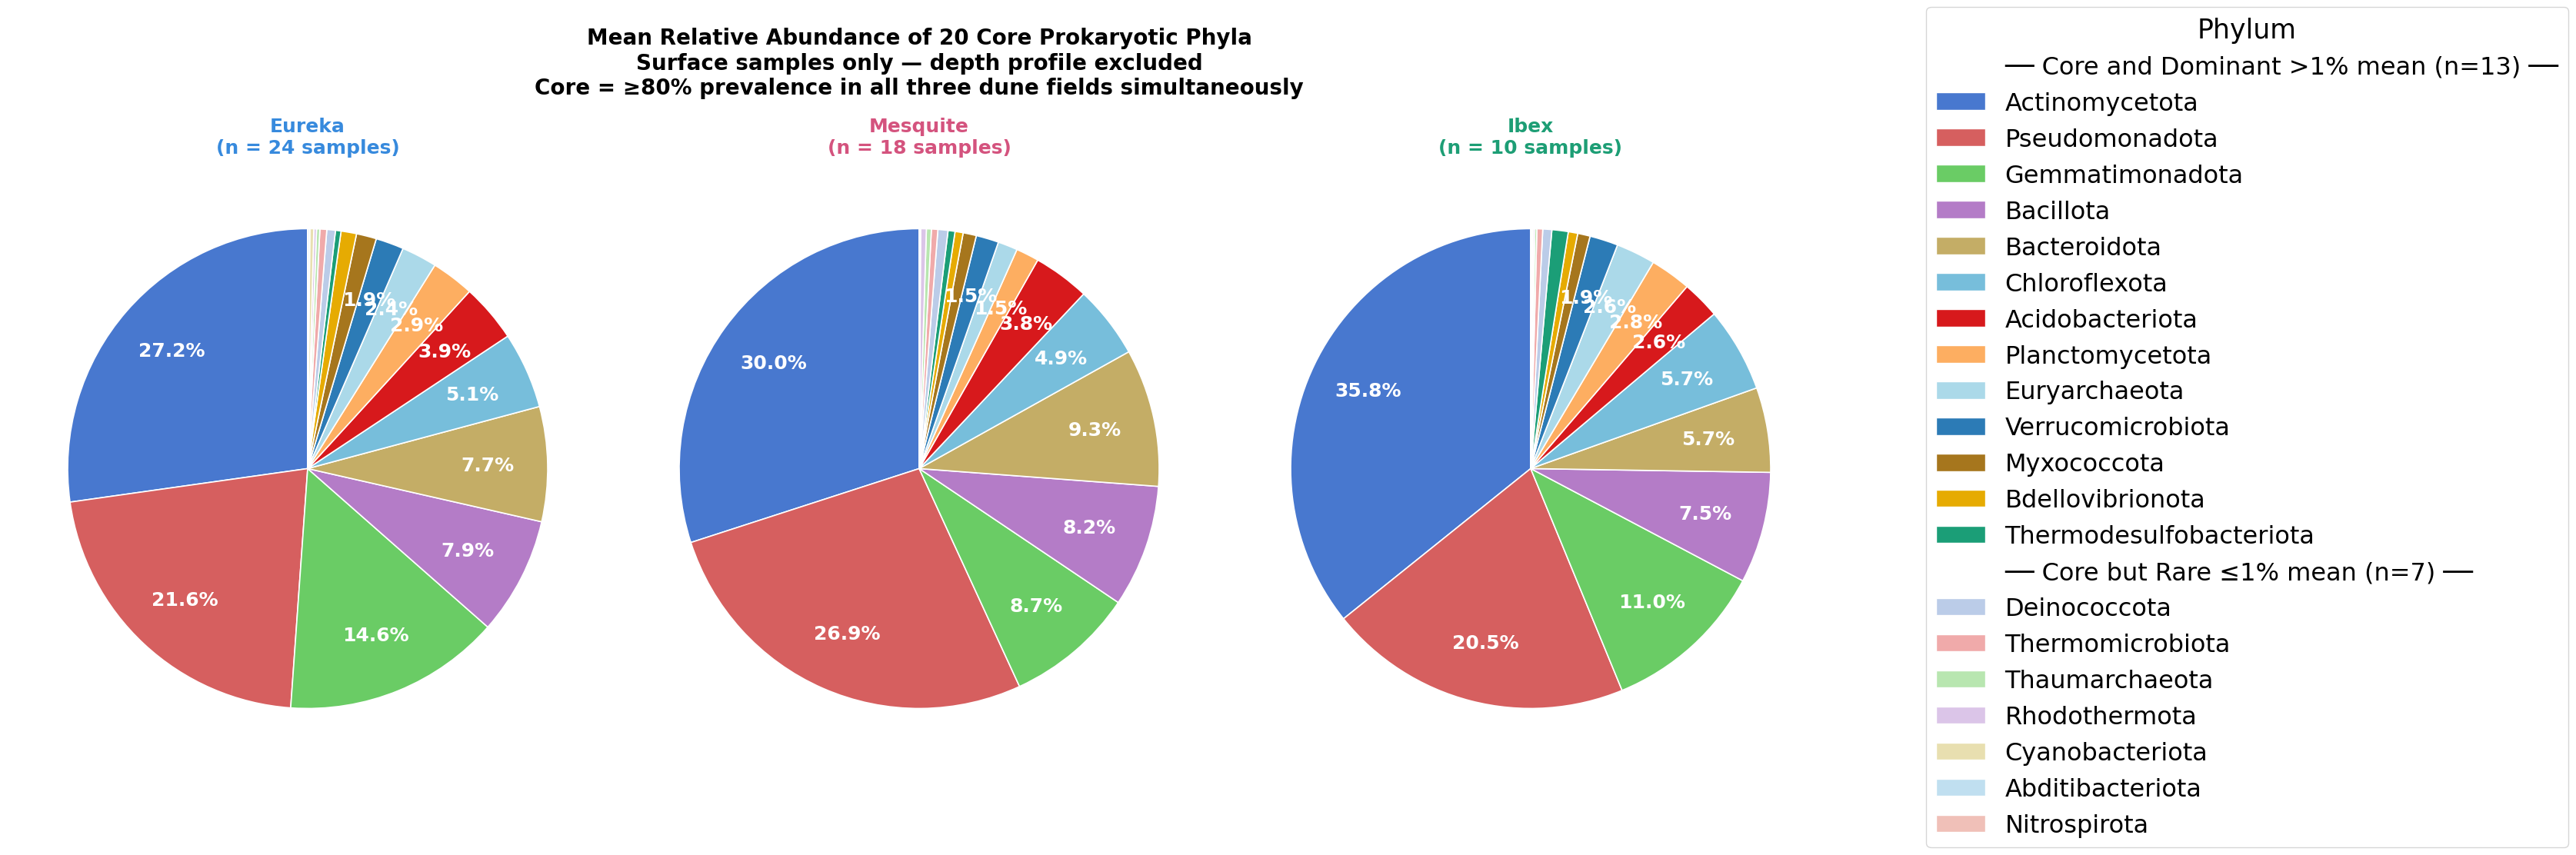

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD FILE
# no depth samples in this file
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# exclude blanks
# ============================
tax_cols    = ["Domain", "Phylum", "Class", "Order",
               "Family", "Genus", "Species"]
zotu_col    = df.columns[0]
sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

print(f"Total samples: {len(sample_cols)}")
print(f"First 3: {sample_cols[:3]}")

# ============================
# FILTER BACTERIA + ARCHAEA
# file already standardised — no rename map needed
# ============================
micro_df = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro_df)}")

# ============================
# FIELD MAP
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_groups = {
    "Eureka":   [s for s in sample_cols if get_field(s) == "Eureka"],
    "Mesquite": [s for s in sample_cols if get_field(s) == "Mesquite"],
    "Ibex":     [s for s in sample_cols if get_field(s) == "Ibex"],
}

print(f"\nEureka:   {len(field_groups['Eureka'])} samples")
print(f"Mesquite: {len(field_groups['Mesquite'])} samples")
print(f"Ibex:     {len(field_groups['Ibex'])} samples")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro_df.groupby("Phylum")[sample_cols].sum()
presence   = (phylum_rel > 0).astype(int)

# ============================
# PREVALENCE + MEAN PER FIELD
# ============================
results = []
for phylum in phylum_rel.index:
    row = {"Phylum": phylum}
    for field, fsamps in field_groups.items():
        row[f"{field}_prev"] = presence.loc[phylum, fsamps].mean()
        row[f"{field}_mean"] = phylum_rel.loc[phylum, fsamps].mean()
    results.append(row)

phylum_df = pd.DataFrame(results)

# ============================
# CORE PHYLA
# ≥80% prevalence in ALL THREE fields
# ============================
core_mask = (
    (phylum_df["Eureka_prev"]   >= 0.80) &
    (phylum_df["Mesquite_prev"] >= 0.80) &
    (phylum_df["Ibex_prev"]     >= 0.80)
)
core_df = phylum_df[core_mask].copy()
core_df["Max_field_mean"] = core_df[[
    "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].max(axis=1)
core_df["Dominant"]     = core_df["Max_field_mean"] >= 1.0
core_df["Overall_mean"] = core_df[[
    "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].mean(axis=1)
core_df = core_df.sort_values(
    "Overall_mean", ascending=False).reset_index(drop=True)

# ============================
# PARTIAL CORE
# ≥80% in 1 or 2 fields only
# ============================
partial_mask = (
    ~core_mask &
    (
        (phylum_df["Eureka_prev"]   >= 0.80) |
        (phylum_df["Mesquite_prev"] >= 0.80) |
        (phylum_df["Ibex_prev"]     >= 0.80)
    )
)
partial_df = phylum_df[partial_mask].copy()

def partial_label(row):
    fields = [f for f in ["Eureka", "Mesquite", "Ibex"]
              if row[f"{f}_prev"] >= 0.80]
    return " + ".join(fields)

partial_df["Fields_core"] = partial_df.apply(partial_label, axis=1)

# ============================
# SUMMARY
# ============================
n_core     = len(core_df)
n_dominant = core_df["Dominant"].sum()
n_rare     = (~core_df["Dominant"]).sum()

print(f"\n{'='*65}")
print(f"CORE PHYLA (surface samples only — depth excluded)")
print(f"{'='*65}")
print(f"\n{'PHYLUM':<35} {'EUREKA':>8} {'MESQUITE':>9} "
      f"{'IBEX':>7} {'OVERALL':>9} {'DOM':>5}")
print("-"*65)
for _, row in core_df.iterrows():
    dom = "YES" if row["Dominant"] else "no"
    print(f"{row['Phylum']:<35} "
          f"{row['Eureka_mean']:>7.2f}% "
          f"{row['Mesquite_mean']:>8.2f}% "
          f"{row['Ibex_mean']:>6.2f}% "
          f"{row['Overall_mean']:>8.2f}% "
          f"{dom:>5}")

print(f"\nTotal core phyla (all 3 fields):      {n_core}")
print(f"Core and dominant (>1% in ≥1 field):  {n_dominant}")
print(f"Core but rare (<1% in all fields):    {n_rare}")
print(f"\nPartial core (1-2 fields only):       {len(partial_df)}")
for _, row in partial_df.iterrows():
    print(f"  {row['Phylum']:<35} {row['Fields_core']}")

for field in ["Eureka", "Mesquite", "Ibex"]:
    n = (phylum_df[f"{field}_prev"] >= 0.80).sum()
    print(f"{field} total core phyla: {n}")

# ============================
# COLOR PALETTE
# consistent color per phylum across all 3 pies
# dominant = vivid, rare = muted
# ============================
dominant_colors = [
    "#4878CF", "#D65F5F", "#6ACC65", "#B47CC7",
    "#C4AD66", "#77BEDB", "#D7191C", "#FDAE61",
    "#ABD9E9", "#2C7BB6", "#A6761D", "#E6AB02",
    "#1B9E77", "#984EA3",
]
rare_colors = [
    "#BBCCE8", "#F0AAAA", "#B8E6B0", "#DBC5E8",
    "#E8DFB0", "#C0DFF0", "#F0C0B8", "#D8C8E8",
]

phylum_color_map = {}
dom_idx  = 0
rare_idx = 0
for _, row in core_df.iterrows():
    if row["Dominant"]:
        phylum_color_map[row["Phylum"]] = dominant_colors[dom_idx]
        dom_idx += 1
    else:
        phylum_color_map[row["Phylum"]] = rare_colors[rare_idx]
        rare_idx += 1

# ============================
# FIGURE — 3 pie charts
# ============================
field_names        = ["Eureka", "Mesquite", "Ibex"]
field_cols         = ["Eureka_mean", "Mesquite_mean", "Ibex_mean"]
field_title_colors = ["#378ADD", "#D4537E", "#1D9E75"]
n_samples          = {f: len(s) for f, s in field_groups.items()}

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.patch.set_facecolor("white")

for ax, field, col, title_color in zip(
        axes, field_names, field_cols, field_title_colors):

    vals   = core_df[col].values
    colors = [phylum_color_map[p] for p in core_df["Phylum"]]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 1.5 else ""

    wedges, texts, autotexts = ax.pie(
        vals,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
    )

    for autotext in autotexts:
        autotext.set_fontsize(18)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    ax.set_title(
        f"{field}\n(n = {n_samples[field]} samples)",
        fontsize=18, fontweight="bold",
        color=title_color, pad=15)

# ============================
# SINGLE LEGEND — phyla listed once
# ============================
legend_handles = []

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core and Dominant >1% mean (n={n_dominant}) ──"))
for _, row in core_df[core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core but Rare ≤1% mean (n={n_rare}) ──"))
for _, row in core_df[~core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.4, 0.5),
    fontsize=23,
    frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=25,
)

fig.suptitle(
    f"Mean Relative Abundance of {n_core} Core Prokaryotic Phyla\n"
    f"Surface samples only — depth profile excluded\n"
    f"Core = ≥80% prevalence in all three dune fields simultaneously",
    fontsize=20, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# See all 36 phyla detected and their domain
print("All phyla detected:")
print(phylum_df[["Phylum", "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].to_string())


All phyla detected:
                         Phylum  Eureka_mean  Mesquite_mean  Ibex_mean
0              abditibacteriota     0.114933       0.027818   0.015393
1               acidobacteriota     3.905160       3.785887   2.551565
2                actinomycetota    27.176002      29.913461  35.610578
3                armatimonadota     0.014851       0.013447   0.069199
4                 atribacterota     0.005338       0.002826   0.015116
5                     bacillota     7.911708       8.223191   7.461079
6                  bacteroidota     7.710667       9.255377   5.685043
7                    balneolota     0.002285       0.013571   0.000000
8              bdellovibrionota     1.040398       0.544462   0.634193
9              campylobacterota     0.006791       0.000000   0.000651
10   candidatus melainabacteria     0.000134       0.000362   0.000636
11  candidatus saccharibacteria     0.014136       0.099448   0.159507
12     candidatus tectomicrobia     0.025254       0.0131

In [ ]:
# ============================
# FINAL OVERLAP SUMMARY
# using field mean criterion throughout
# ============================

# dominant = >1% mean in at least one field (across ALL phyla, not just core)
all_phyla_dominant = (
    phylum_df[["Eureka_mean", "Mesquite_mean", "Ibex_mean"]]
    .max(axis=1) >= 1.0
).sum()

# dominant but not core
dominant_not_core = (
    phylum_df[
        ~core_mask &
        (phylum_df[["Eureka_mean","Mesquite_mean","Ibex_mean"]].max(axis=1) >= 1.0)
    ]
)

print("\n=== FINAL OVERLAP SUMMARY ===")
print(f"Total prokaryotic phyla detected:                  {len(phylum_df)}")
print(f"Phyla exceeding 1% mean in at least one field:    {all_phyla_dominant}")
print(f"Core phyla (≥80% prevalence in all three fields): {n_core}")
print(f"Both core AND dominant:                           {n_dominant}")
print(f"Core but never >1% mean in any field:             {n_rare}")
print(f"Dominant but not core:                            {len(dominant_not_core)}")
print(f"Total unique core phyla (incl. partial fields):   {n_total_unique}")

if len(dominant_not_core) > 0:
    print(f"\nDominant but not core phyla:")
    for _, row in dominant_not_core.iterrows():
        print(f"  {row['Phylum']:<35} "
              f"Eureka: {row['Eureka_mean']:.2f}%  "
              f"Mesquite: {row['Mesquite_mean']:.2f}%  "
              f"Ibex: {row['Ibex_mean']:.2f}%  "
              f"Prev: E={row['Eureka_prev']:.0%} "
              f"M={row['Mesquite_prev']:.0%} "
              f"I={row['Ibex_prev']:.0%}")


=== FINAL OVERLAP SUMMARY ===
Total prokaryotic phyla detected:                  36
Phyla exceeding 1% mean in at least one field:    13
Core phyla (≥80% prevalence in all three fields): 20
Both core AND dominant:                           13
Core but never >1% mean in any field:             7
Dominant but not core:                            0
Total unique core phyla (incl. partial fields):   27


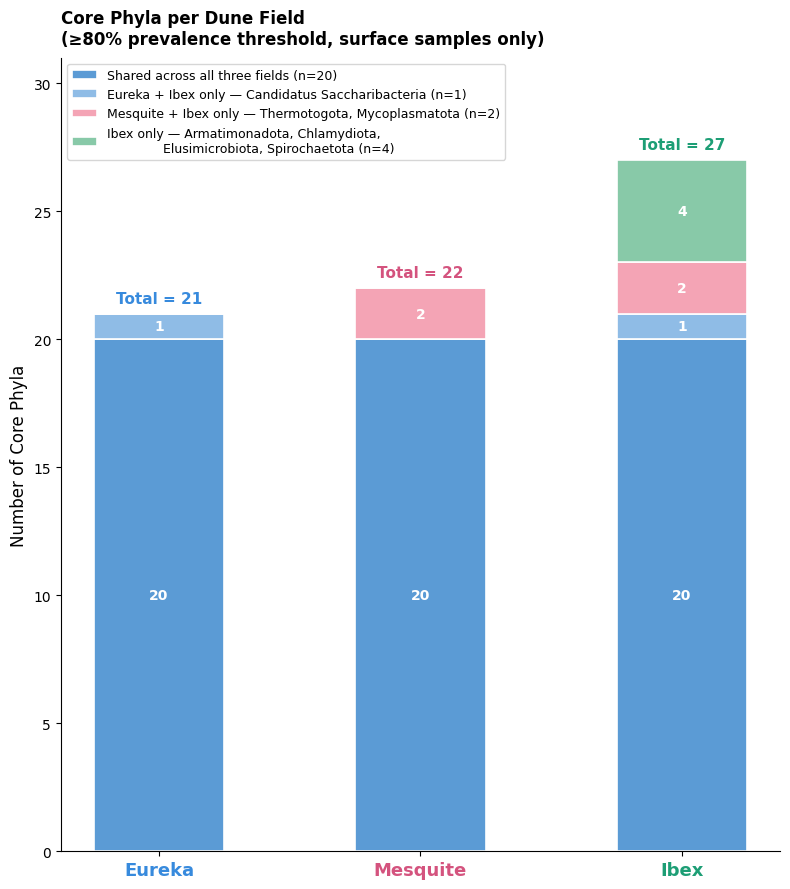

Saved: core_phyla_stacked_surface.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# UPDATED VALUES FROM SURFACE-ONLY ANALYSIS
# ============================
fields = ['Eureka', 'Mesquite', 'Ibex']

# shared across all three fields
shared_all3 = [20, 20, 20]

# Eureka + Ibex only — Candidatus Saccharibacteria
eu_ib_only  = [1, 0, 1]

# Mesquite + Ibex only — Thermotogota, Mycoplasmatota
me_ib_only  = [0, 2, 2]

# Ibex only — Armatimonadota, Chlamydiota,
#             Elusimicrobiota, Spirochaetota
ibex_only   = [0, 0, 4]

# Mesquite only — none
me_only     = [0, 0, 0]

# totals from output
totals = [21, 22, 27]

field_colors = {
    'Eureka':   '#378ADD',
    'Mesquite': '#D4537E',
    'Ibex':     '#1D9E75'
}

x     = np.arange(len(fields))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 9))
fig.patch.set_facecolor("white")

# ============================
# STACKED BARS
# ============================
b1 = ax.bar(x, shared_all3, width,
            label='Shared across all three fields (n=20)',
            color='#5B9BD5', edgecolor='white', linewidth=1.2)

bottom1 = np.array(shared_all3)

b2 = ax.bar(x, eu_ib_only, width,
            bottom=bottom1,
            label='Eureka + Ibex only — Candidatus Saccharibacteria (n=1)',
            color='#8FBCE6', edgecolor='white', linewidth=1.2)

bottom2 = bottom1 + np.array(eu_ib_only)

b3 = ax.bar(x, me_ib_only, width,
            bottom=bottom2,
            label='Mesquite + Ibex only — Thermotogota, Mycoplasmatota (n=2)',
            color='#F4A4B5', edgecolor='white', linewidth=1.2)

bottom3 = bottom2 + np.array(me_ib_only)

b4 = ax.bar(x, ibex_only, width,
            bottom=bottom3,
            label='Ibex only — Armatimonadota, Chlamydiota,\n'
                  '              Elusimicrobiota, Spirochaetota (n=4)',
            color='#88C9A8', edgecolor='white', linewidth=1.2)

# ============================
# TOTAL LABELS ABOVE BARS
# ============================
for i, (total, field) in enumerate(zip(totals, fields)):
    ax.text(i, total + 0.3,
            f'Total = {total}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            color=field_colors[field])

# ============================
# VALUE LABELS INSIDE BARS
# ============================
for bar_group, values, bottoms in [
    (b1, shared_all3, np.zeros(3)),
    (b2, eu_ib_only,  bottom1),
    (b3, me_ib_only,  bottom2),
    (b4, ibex_only,   bottom3),
]:
    for bar, val, bot in zip(bar_group, values, bottoms):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2,
                    str(val),
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white')

# ============================
# FORMATTING
# ============================
ax.set_xticks(x)
ax.set_xticklabels(fields, fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Core Phyla', fontsize=12)
ax.set_ylim(0, 31)
ax.set_title(
    'Core Phyla per Dune Field\n'
    '(≥80% prevalence threshold, surface samples only)',
    fontsize=12, fontweight='bold', loc='left', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for tick, field in zip(ax.get_xticklabels(), fields):
    tick.set_color(field_colors[field])

ax.legend(fontsize=9, frameon=True,
          edgecolor='#CCCCCC', loc='upper left')

plt.tight_layout()
plt.show()


Total samples: 52
Eureka: 24  Mesquite: 18  Ibex: 10
Prokaryotic ZOTUs: 5892

Dominant prokaryotic phyla (>1% mean): 13
                 Phylum  Eureka_mean  Mesquite_mean  Ibex_mean
         actinomycetota    27.176002      29.913461  35.610578
         pseudomonadota    21.594364      26.816741  20.367664
        gemmatimonadota    14.609477       8.684047  10.986598
           bacteroidota     7.710667       9.255377   5.685043
              bacillota     7.911708       8.223191   7.461079
          chloroflexota     5.132962       4.872717   5.664149
        acidobacteriota     3.905160       3.785887   2.551565
        planctomycetota     2.877841       1.544392   2.746086
          euryarchaeota     2.383495       1.319839   2.626849
      verrucomicrobiota     1.883729       1.522023   1.902747
            myxococcota     1.346514       0.890710   0.834358
thermodesulfobacteriota     0.372305       0.466528   1.093230
       bdellovibrionota     1.040398       0.544462   0.63419

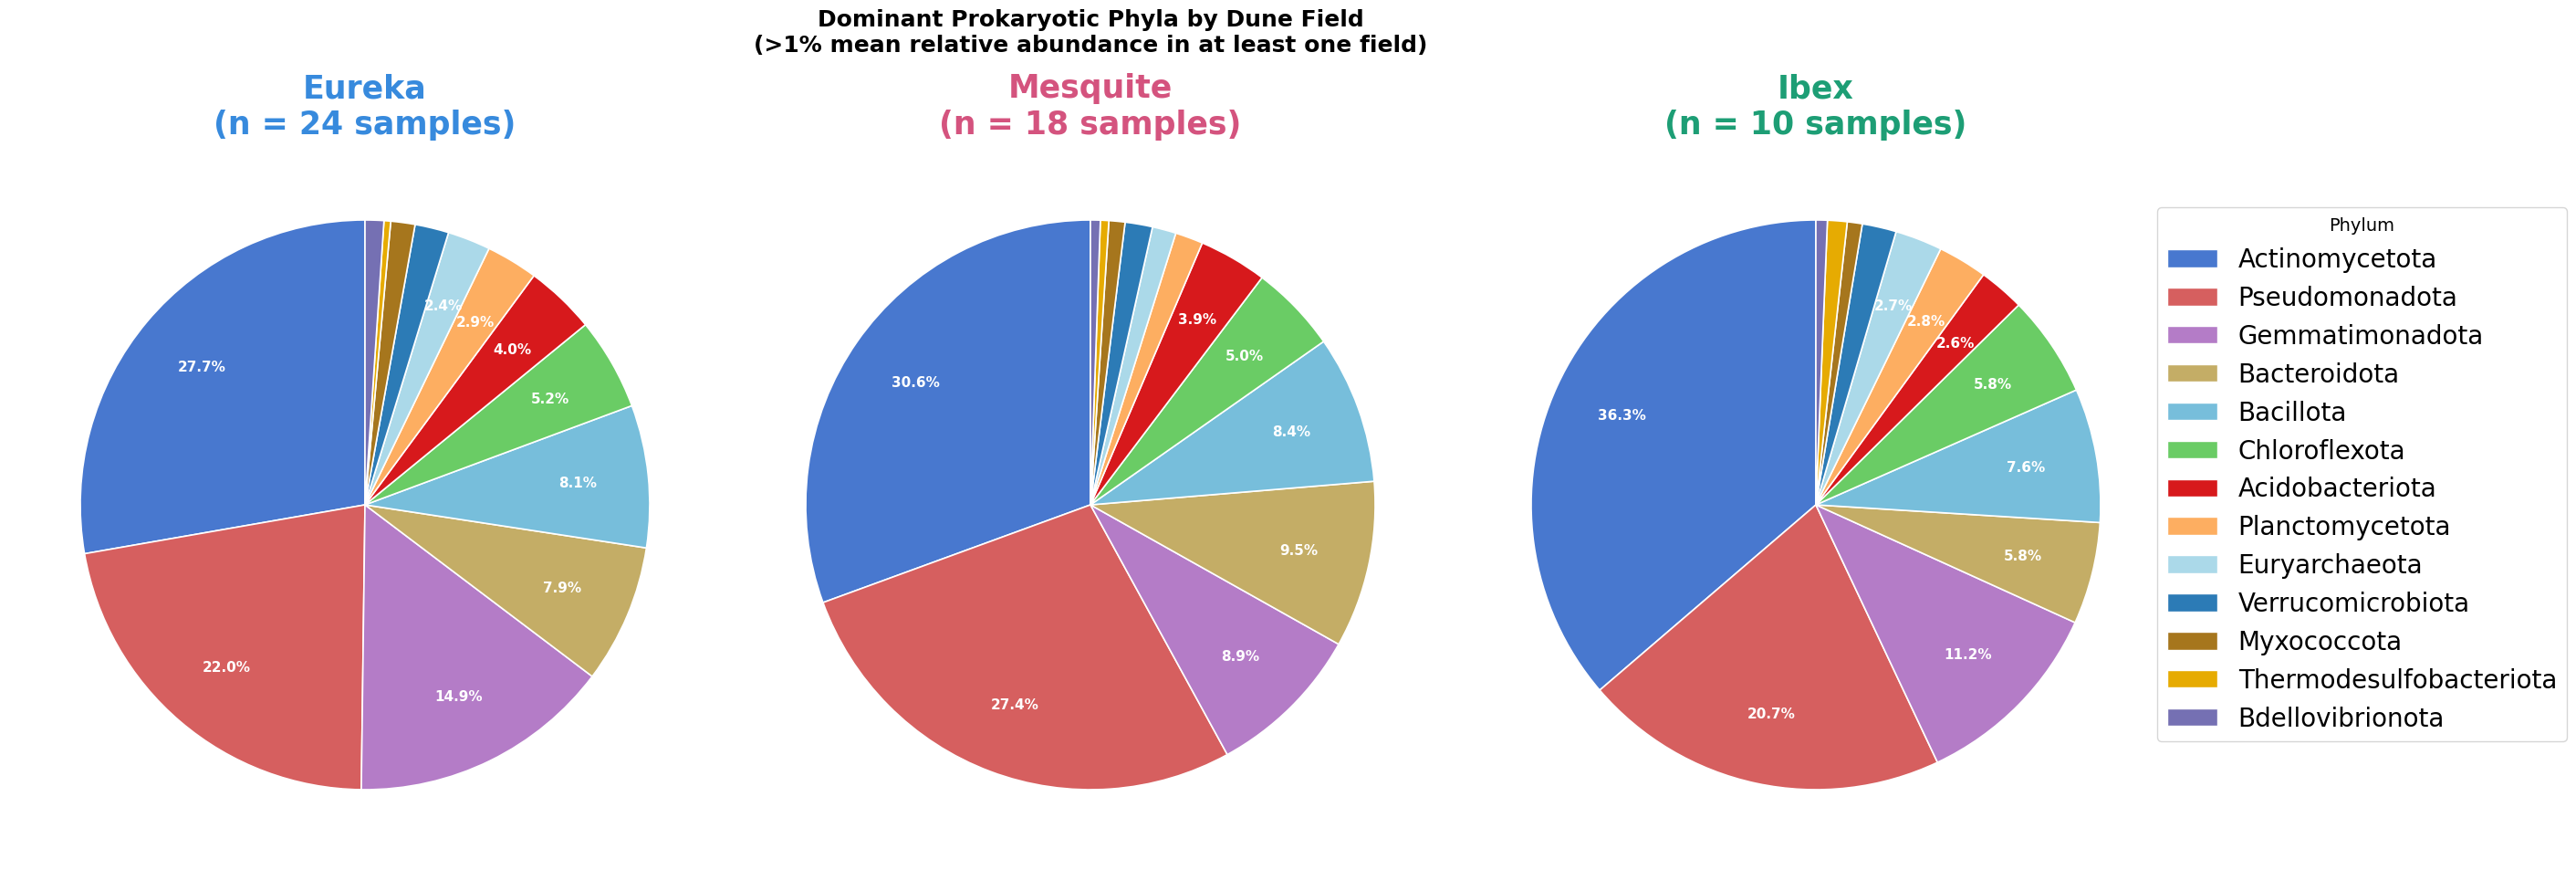

Saved: dominant_phyla_pies_prokaryotes.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

print(f"Total samples: {len(sample_cols)}")

# ============================
# FIELD MAP
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]

field_groups = {
    "Eureka":   eureka_samples,
    "Mesquite": mesquite_samples,
    "Ibex":     ibex_samples,
}

print(f"Eureka: {len(eureka_samples)}  "
      f"Mesquite: {len(mesquite_samples)}  "
      f"Ibex: {len(ibex_samples)}")

# ============================
# FILTER BACTERIA + ARCHAEA TOGETHER
# ============================
micro_df = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro_df)}")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro_df.groupby("Phylum")[sample_cols].sum()

# ============================
# FIELD MEANS AND DOMINANCE
# ============================
results = []
for phylum in phylum_rel.index:
    row = {"Phylum": phylum}
    for field, fsamps in field_groups.items():
        row[f"{field}_mean"] = phylum_rel.loc[phylum, fsamps].mean()
    results.append(row)

stats_df = pd.DataFrame(results)
stats_df["Max_field_mean"] = stats_df[[
    "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].max(axis=1)
stats_df["Dominant"] = stats_df["Max_field_mean"] >= 1.0
stats_df = stats_df.sort_values(
    "Max_field_mean", ascending=False).reset_index(drop=True)

dom_df = stats_df[stats_df["Dominant"]].copy()

print(f"\nDominant prokaryotic phyla (>1% mean): {len(dom_df)}")
print(dom_df[["Phylum", "Eureka_mean",
              "Mesquite_mean", "Ibex_mean"]].to_string(index=False))

# ============================
# COLOR PALETTE
# one color per phylum consistent across all 3 pies
# ============================
color_list = [
    '#4878CF','#D65F5F','#B47CC7','#C4AD66','#77BEDB',
    '#6ACC65','#D7191C','#FDAE61','#ABD9E9','#2C7BB6',
    '#A6761D','#E6AB02','#7570B3','#E7298A','#66A61E',
    '#FF7F0E','#1B9E77',
]

color_map = {
    row["Phylum"]: color_list[i]
    for i, (_, row) in enumerate(dom_df.iterrows())
}

# ============================
# FIGURE — 3 pie charts
# ============================
field_names        = ["Eureka", "Mesquite", "Ibex"]
field_cols         = ["Eureka_mean", "Mesquite_mean", "Ibex_mean"]
field_title_colors = ["#378ADD", "#D4537E", "#1D9E75"]
n_samples          = {f: len(s) for f, s in field_groups.items()}

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.patch.set_facecolor("white")

for ax, field, col, title_color in zip(
        axes, field_names, field_cols, field_title_colors):

    vals   = dom_df[col].values
    colors = [color_map[p] for p in dom_df["Phylum"]]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 2.0 else ""

    wedges, texts, autotexts = ax.pie(
        vals,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
    )
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    ax.set_title(
        f"{field}\n(n = {n_samples[field]} samples)",
        fontsize=25, fontweight="bold",
        color=title_color, pad=12)

# ============================
# SINGLE LEGEND — phyla listed once
# ============================
legend_handles = [
    Patch(facecolor=color_map[row["Phylum"]],
          edgecolor="white",
          label=row["Phylum"].capitalize())
    for _, row in dom_df.iterrows()
]

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=20, frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=14,
)

fig.suptitle(
    "Dominant Prokaryotic Phyla by Dune Field\n"
    "(>1% mean relative abundance in at least one field)",
    fontsize=18, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("dominant_phyla_pies_prokaryotes.png",
            dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: dominant_phyla_pies_prokaryotes.png")

Significant phyla before quality filtering: 14

QUALITY FILTER  —  must pass ALL three thresholds to be included
  Mean reads    ≥ 5.0
  Prevalence    ≥ 20% of samples
  % of dataset  ≥ 0.01%

PHYLUM                                 READS     PREV    %DATA    PASS?
---------------------------------------------------------------------------
acidobacteriota                      1112.9   100.0%   3.6056%      KEEP
actinomycetota                       9219.8   100.0%  29.8709%      KEEP
bacteroidota                         2431.7   100.0%   7.8785%      KEEP
balneolota                              1.8    13.5%   0.0058%    REMOVE
bdellovibrionota                      244.7   100.0%   0.7928%      KEEP
chlamydiota                             2.4    30.8%   0.0078%    REMOVE
cyanobacteriota                        46.4   100.0%   0.1502%      KEEP
euryarchaeota                         633.5   100.0%   2.0525%      KEEP
fusobacteriota                          0.4    28.8%   0.0014%    REMOVE
ki

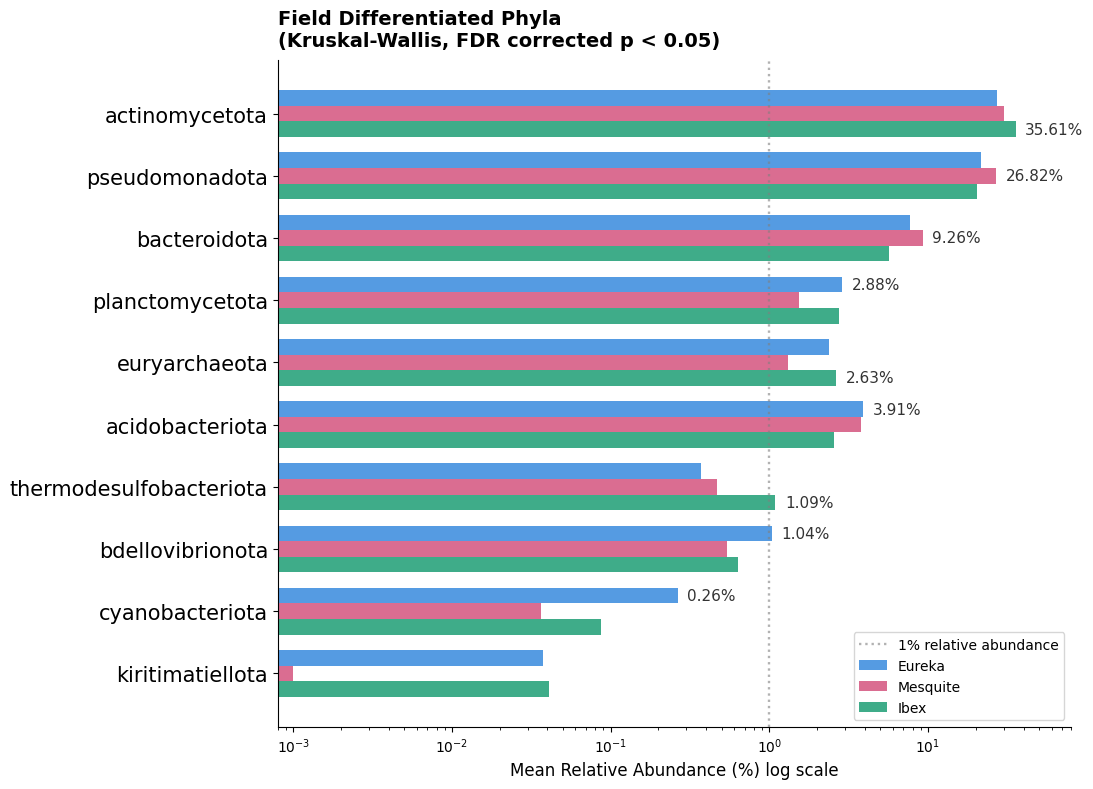

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# ============================
# QUALITY FILTER THRESHOLDS
# Change these values to adjust stringency
# ============================
MIN_MEAN_READS  = 5.0    # minimum mean reads per sample
MIN_PREVALENCE  = 0.20   # minimum proportion of samples with any reads
MIN_PCT_DATASET = 0.01   # minimum % of total dataset reads

# ============================
# LOAD RELATIVE ABUNDANCE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

sample_cols = [s for s in df.columns[1:-7] if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# PHYLUM RENAME MAP
# ============================
rename_map = {
    'actinobacteria':        'actinomycetota',
    'firmicutes':            'bacillota',
    'bacteroidetes':         'bacteroidota',
    'chloroflexi':           'chloroflexota',
    'cyanobacteria':         'cyanobacteriota',
    'proteobacteria':        'pseudomonadota',
    'pseudomonadot':         'pseudomonadota',
    'planctomycetes':        'planctomycetota',
    'gemmatimonadetes':      'gemmatimonadota',
    'verrucomicrobia':       'verrucomicrobiota',
    'acidobacteria':         'acidobacteriota',
    'nitrospirae':           'nitrospirota',
    'chlamydiae':            'chlamydiota',
    'elusimicrobia':         'elusimicrobiota',
    'spirochaetes':          'spirochaetota',
    'tenericutes':           'mycoplasmatota',
    'fusobacteria':          'fusobacteriota',
    'thermodesulfobacteria': 'thermodesulfobacteriota',
    'deinococcus-thermus':   'deinococcota',
    'armatimonadetes':       'armatimonadota',
    'thermotogae':           'thermotogota',
}

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip().replace(rename_map)

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro = df[df["Domain"].isin(["bacteria", "archaea"])].copy()
micro = micro[micro["Phylum"] != "bacteria"]

def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_map = {s: get_field(s) for s in sample_cols}

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro.groupby("Phylum")[sample_cols].sum()

# ============================
# LOAD RAW COUNTS FOR QUALITY CHECK
# ============================
cnt_path = "/content/zotutab_decontam_Final.csv"
raw_cnt  = pd.read_csv(cnt_path, header=None)
df_cnt   = raw_cnt.iloc[2:].copy()
df_cnt.columns = raw_cnt.iloc[1]
df_cnt.reset_index(drop=True, inplace=True)

cnt_cols = [s for s in df_cnt.columns[1:-7] if "Blank" not in str(s)]
df_cnt[cnt_cols] = df_cnt[cnt_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
df_cnt["Domain"] = df_cnt["Domain"].str.lower().str.strip()
df_cnt["Phylum"] = df_cnt["Phylum"].str.lower().str.strip().replace(rename_map)

micro_cnt   = df_cnt[df_cnt["Domain"].isin(["bacteria","archaea"])].copy()
phylum_cnt  = micro_cnt.groupby("Phylum")[cnt_cols].sum()
total_reads = phylum_cnt.values.sum()

# ============================
# KRUSKAL-WALLIS + FDR
# ============================
kw_results = []
for phylum in phylum_rel.index:
    groups = [phylum_rel.loc[phylum, [s for s in sample_cols if field_map[s] == f]]
              for f in ["Eureka", "Mesquite", "Ibex"]]
    if any(len(g) == 0 for g in groups):
        continue
    stat, p = kruskal(*groups)
    kw_results.append({
        "Phylum":        phylum,
        "p_value":       p,
        "Eureka_mean":   groups[0].mean(),
        "Mesquite_mean": groups[1].mean(),
        "Ibex_mean":     groups[2].mean(),
    })

kw_df = pd.DataFrame(kw_results)
kw_df["p_adj"] = multipletests(kw_df["p_value"], method="fdr_bh")[1]
sig_phyla = kw_df[kw_df["p_adj"] < 0.05].copy()

print(f"Significant phyla before quality filtering: {len(sig_phyla)}")

# ============================
# STRICT QUALITY FILTER
# A phylum must PASS ALL THREE checks to be included
# ============================
print("\n" + "="*75)
print(f"QUALITY FILTER  —  must pass ALL three thresholds to be included")
print(f"  Mean reads    ≥ {MIN_MEAN_READS}")
print(f"  Prevalence    ≥ {MIN_PREVALENCE*100:.0f}% of samples")
print(f"  % of dataset  ≥ {MIN_PCT_DATASET}%")
print("="*75)
print(f"\n{'PHYLUM':<35} {'READS':>8} {'PREV':>8} {'%DATA':>8} {'PASS?':>8}")
print("-"*75)

keep = []
for _, row in sig_phyla.iterrows():
    p = row["Phylum"]

    if p not in phylum_cnt.index:
        print(f"{p:<35} {'NOT IN COUNT TABLE':>35} {'FAIL':>8}")
        continue

    counts     = phylum_cnt.loc[p, cnt_cols]
    mean_reads = counts.mean()
    prevalence = (counts > 0).sum() / len(cnt_cols)
    pct_total  = counts.sum() / total_reads * 100

    passes = (
        mean_reads  >= MIN_MEAN_READS  and
        prevalence  >= MIN_PREVALENCE  and
        pct_total   >= MIN_PCT_DATASET
    )

    status = "KEEP" if passes else "REMOVE"
    print(f"{p:<35} {mean_reads:>7.1f}  "
          f"{prevalence*100:>6.1f}%  "
          f"{pct_total:>7.4f}%  "
          f"{status:>8}")

    if passes:
        keep.append(row)

final_df = pd.DataFrame(keep).reset_index(drop=True)
final_df = final_df.sort_values("Ibex_mean", ascending=True).reset_index(drop=True)

print(f"\nFinal phyla after quality filtering: {len(final_df)}")
print(final_df[["Phylum","Eureka_mean","Mesquite_mean",
                "Ibex_mean","p_adj"]].to_string())

# ============================
# FIGURE
# ============================
phyla_s    = final_df["Phylum"].tolist()
eureka_s   = final_df["Eureka_mean"].tolist()
mesquite_s = final_df["Mesquite_mean"].tolist()
ibex_s     = final_df["Ibex_mean"].tolist()

field_colors = {
    'Eureka':   '#378ADD',
    'Mesquite': '#D4537E',
    'Ibex':     '#1D9E75'
}

min_val       = 0.001
eureka_plot   = [max(v, min_val) for v in eureka_s]
mesquite_plot = [max(v, min_val) for v in mesquite_s]
ibex_plot     = [max(v, min_val) for v in ibex_s]

y      = np.arange(len(phyla_s))
height = 0.25

fig, ax = plt.subplots(figsize=(11, max(6, len(phyla_s) * 0.8)))

ax.barh(y + height, eureka_plot,   height,
        label='Eureka',   color=field_colors['Eureka'],   alpha=0.85)
ax.barh(y,           mesquite_plot, height,
        label='Mesquite', color=field_colors['Mesquite'], alpha=0.85)
ax.barh(y - height,  ibex_plot,    height,
        label='Ibex',     color=field_colors['Ibex'],     alpha=0.85)

ax.set_xscale('log')
ax.set_xlim(0.0008, 80)
ax.set_yticks(y)
ax.set_yticklabels(phyla_s, fontsize=15)

ax.axvline(x=1.0, color='gray', linestyle=':',
           linewidth=1.7, alpha=0.6, label='1% relative abundance')

for i, (e, m, ib) in enumerate(zip(eureka_s, mesquite_s, ibex_s)):
    max_val = max(e, m, ib)
    if max_val >= 0.1:
        y_pos = (i + height if max_val == e else
                 i          if max_val == m else
                 i - height)
        ax.text(max_val * 1.15, y_pos,
                f'{max_val:.2f}%',
                va='center', fontsize=11, color='#333333')

ax.set_xlabel('Mean Relative Abundance (%) log scale', fontsize=12)
ax.set_title(
    f'Field Differentiated Phyla \n'
    f'(Kruskal-Wallis, FDR corrected p < 0.05)',
    fontsize=14, fontweight='bold', loc='left', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, frameon=True, edgecolor='#CCCCCC', loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 30.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova

# ============================
# LOAD FILE
# already standardised — no rename map needed
# ============================
relabund_path = '/content/zotutab_decontam_RelAbund_Final.csv'

raw_rel = pd.read_csv(relabund_path, header=None)
df_rel  = raw_rel.iloc[2:].copy()
df_rel.columns = raw_rel.iloc[1]
df_rel.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df_rel.columns[0]

sample_cols = [c for c in df_rel.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df_rel[sample_cols] = df_rel[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_rel["Domain"] = df_rel["Domain"].str.lower().str.strip()
df_rel["Phylum"] = df_rel["Phylum"].str.lower().str.strip()

# ============================
# FILTER BACTERIA + ARCHAEA
# file already clean — just filter by domain
# ============================
micro = df_rel[
    df_rel["Domain"].isin(["bacteria", "archaea"]) &
    (df_rel["Phylum"] != "bacteria") &
    df_rel["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]
all_samples      = eureka_samples + mesquite_samples + ibex_samples
shared           = all_samples

metadata = pd.DataFrame(
    {"Field": [get_field(s) for s in all_samples]},
    index=all_samples
)
meta_aln = metadata.copy()

print(f"Eureka: {len(eureka_samples)}  "
      f"Mesquite: {len(mesquite_samples)}  "
      f"Ibex: {len(ibex_samples)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
zotu_id_col = micro.columns[0]

relabund_t = (
    micro
    .set_index(zotu_id_col)[sample_cols]
    .T
    .fillna(0)
)
relabund_t = relabund_t.loc[
    relabund_t.index.isin(all_samples)
].reindex(all_samples)
relabund_t.index.name   = None
relabund_t.columns.name = None

print(f"Sample x ZOTU matrix: {relabund_t.shape}")

# ============================
# ZOTU-LEVEL RARE/DOMINANT SPLIT
# individual sample maximum per ZOTU
# ============================
zotu_max_sample = relabund_t.max(axis=0)
rare_zotus      = zotu_max_sample[zotu_max_sample <= 1.0].index
dominant_zotus  = zotu_max_sample[zotu_max_sample >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_id_col)["Phylum"].to_dict()
core_zotus  = [z for z in relabund_t.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# BUILD FOUR SUBSETS
# ============================
all_taxa     = relabund_t.copy()
rare_only    = relabund_t[rare_zotus].copy()
rare_removed = relabund_t[dominant_zotus].copy()
core_only    = relabund_t[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa ZOTUs:     {all_taxa.shape[1]}")
print(f"  Rare only ZOTUs:    {rare_only.shape[1]}")
print(f"  Rare removed ZOTUs: {rare_removed.shape[1]}")
print(f"  Core only ZOTUs:    {core_only.shape[1]}")
print(f"  Core phyla used:    {len(core_phyla)}")

# ============================
# PCoA FUNCTION
# ============================
def pcoa(dist_arr):
    D2         = dist_arr ** 2
    row_mean   = D2.mean(axis=1, keepdims=True)
    col_mean   = D2.mean(axis=0, keepdims=True)
    grand_mean = D2.mean()
    B          = -0.5 * (D2 - row_mean - col_mean + grand_mean)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos     = eigvals > 0
    coords  = eigvecs[:, pos] * np.sqrt(eigvals[pos])
    var_exp = eigvals[pos] / eigvals[pos].sum() * 100
    return coords, var_exp

# ============================
# BRAY-CURTIS DISTANCE
# ============================
def bray_curtis_dm(df):
    arr = df.values.astype(float)
    bc  = squareform(pdist(arr, metric="braycurtis"))
    return np.nan_to_num(bc, nan=1.0)

print("\nComputing distance matrices...")
dm_all      = bray_curtis_dm(all_taxa)
dm_rare     = bray_curtis_dm(rare_only)
dm_no_rare  = bray_curtis_dm(rare_removed)
dm_core     = bray_curtis_dm(core_only)
print("Done.")

print("Running PCoA...")
coords_all,     var_all     = pcoa(dm_all)
coords_rare,    var_rare    = pcoa(dm_rare)
coords_no_rare, var_no_rare = pcoa(dm_no_rare)
coords_core,    var_core    = pcoa(dm_core)
print("Done.")

print("\nVariance explained:")
for label, var in [
    ("All taxa",     var_all),
    ("Rare only",    var_rare),
    ("Rare removed", var_no_rare),
    ("Core only",    var_core),
]:
    print(f"  [{label:<15}]  PCo1: {var[0]:.1f}%  PCo2: {var[1]:.1f}%")

# ============================
# PERMANOVA — Anderson (2001) verified formula
# ============================
def run_permanova(dm_arr, grouping, label, n_perm=999):
    groups  = np.array(grouping)
    n       = len(groups)
    unique  = np.unique(groups)

    ss_total  = np.sum(dm_arr ** 2) / n
    ss_within = sum(
        np.sum(dm_arr[np.ix_(np.where(groups == g)[0],
                              np.where(groups == g)[0])] ** 2) /
        len(np.where(groups == g)[0])
        for g in unique if len(np.where(groups == g)[0]) > 1
    )
    r2 = (ss_total - ss_within) / ss_total if ss_total > 0 else 0

    dm_obj = DistanceMatrix(dm_arr, ids=all_samples)
    meta   = pd.Series(groups, index=all_samples, name="Group")
    result = permanova(dm_obj, meta,
                       column="Group", permutations=n_perm)
    p_val  = result["p-value"]
    f_stat = result["test statistic"]

    print(f"  {label:<20}  R² = {r2*100:.1f}%  "
          f"F = {f_stat:.2f}  p = {p_val:.3f}")
    return r2, p_val, f_stat

field_groups_list = [get_field(s) for s in all_samples]

print("\nPERMANOVA — Field identity (Anderson 2001 R²):")
print("-" * 55)
for dm_arr, label in [
    (dm_all,     "All taxa"),
    (dm_rare,    "Rare only"),
    (dm_no_rare, "Rare removed"),
    (dm_core,    "Core only"),
]:
    run_permanova(dm_arr, field_groups_list, label)

Prokaryotic ZOTUs: 5892
Eureka: 24  Mesquite: 18  Ibex: 10
Sample x ZOTU matrix: (52, 5892)

Subset sizes:
  All taxa ZOTUs:     5892
  Rare only ZOTUs:    5611
  Rare removed ZOTUs: 283
  Core only ZOTUs:    5834
  Core phyla used:    20

Computing distance matrices...
Done.
Running PCoA...
Done.

Variance explained:
  [All taxa       ]  PCo1: 14.5%  PCo2: 9.2%
  [Rare only      ]  PCo1: 8.8%  PCo2: 6.2%
  [Rare removed   ]  PCo1: 20.3%  PCo2: 10.7%
  [Core only      ]  PCo1: 14.5%  PCo2: 9.2%

PERMANOVA — Field identity (Anderson 2001 R²):
-------------------------------------------------------
  All taxa              R² = 14.8%  F = 4.26  p = 0.001
  Rare only             R² = 11.5%  F = 3.18  p = 0.001
  Rare removed          R² = 17.2%  F = 5.09  p = 0.001
  Core only             R² = 14.8%  F = 4.26  p = 0.001


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp

np.random.seed(42)

# ============================
# PATHS
# ============================
REL_PATH  = "/content/zotutab_decontam_RelAbund_Final.csv"
META_PATH = "/content/PERM_metadata.csv"

# ============================
# PHYLUM RENAME MAP
# ============================
rename_map = {
    'actinobacteria':        'actinomycetota',
    'firmicutes':            'bacillota',
    'bacteroidetes':         'bacteroidota',
    'chloroflexi':           'chloroflexota',
    'cyanobacteria':         'cyanobacteriota',
    'proteobacteria':        'pseudomonadota',
    'pseudomonadot':         'pseudomonadota',
    'planctomycetes':        'planctomycetota',
    'gemmatimonadetes':      'gemmatimonadota',
    'verrucomicrobia':       'verrucomicrobiota',
    'acidobacteria':         'acidobacteriota',
    'nitrospirae':           'nitrospirota',
    'chlamydiae':            'chlamydiota',
    'elusimicrobia':         'elusimicrobiota',
    'spirochaetes':          'spirochaetota',
    'tenericutes':           'mycoplasmatota',
    'fusobacteria':          'fusobacteriota',
    'thermodesulfobacteria': 'thermodesulfobacteriota',
    'deinococcus-thermus':   'deinococcota',
    'armatimonadetes':       'armatimonadota',
    'thermotogae':           'thermotogota',
}

eukaryote_phyla = [
    'chlorophyta', 'discosea', 'eukaryota', 'tubulinea',
    'phaeophyceae', 'streptophyta', 'bacillariophyta', 'chordata',
    'ciliophora', 'oomycota', 'basidiomycota', 'eustigmatophyceae',
    'ascomycota', 'choanoflagellatea',
]

# ============================
# LOAD RELATIVE ABUNDANCE
# ============================
raw = pd.read_csv(REL_PATH, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

sample_cols = [s for s in df.columns[1:-7] if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip().replace(rename_map)

micro_df = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    ~df["Phylum"].isin(eukaryote_phyla) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna() &
    ~df["Phylum"].str.startswith("unclassified", na=True)
].copy()

print(f"Total ZOTUs (bacteria + archaea): {len(micro_df)}")

# ============================
# LOAD & ALIGN METADATA
# ============================
meta = pd.read_csv(META_PATH).rename(columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(sample_cols) & set(meta.index))
meta_aln = meta.loc[shared].copy()

cont_vars = ["GrainSize", "Moisture"]
for c in cont_vars:
    meta_aln[c] = pd.to_numeric(meta_aln[c], errors="coerce")
meta_aln[cont_vars] = meta_aln[cont_vars].fillna(meta_aln[cont_vars].median())

# strip whitespace from morphology — critical for marker matching
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

print(f"Shared samples: {len(shared)}")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in shared if get_field(s) == "Eureka"]
mesquite_samples = [s for s in shared if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in shared if get_field(s) == "Ibex"]

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
zotu_id_col = micro_df.columns[0]

relabund_t = (
    micro_df.set_index(zotu_id_col)[shared]
    .T.fillna(0)
)
relabund_t = relabund_t.reindex(shared)
relabund_t.index.name   = None
relabund_t.columns.name = None

print(f"Sample x ZOTU matrix: {relabund_t.shape}")

# ============================
# RARE / DOMINANT SPLIT
# individual sample max — standard for ZOTU level
# ============================
zotu_max    = relabund_t.max(axis=0)
rare_zotus  = zotu_max[zotu_max <= 1.0].index
dom_zotus   = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence within each field separately
# ============================
phylum_grouped = micro_df.groupby("Phylum")[shared].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro_df.set_index(zotu_id_col)["Phylum"].to_dict()
core_zotus  = [z for z in relabund_t.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# FOUR SUBSETS
# ============================
all_taxa     = relabund_t.copy()
rare_only    = relabund_t[rare_zotus].copy()
rare_removed = relabund_t[dom_zotus].copy()
core_only    = relabund_t[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa ZOTUs:     {all_taxa.shape[1]}")
print(f"  Rare only ZOTUs:    {rare_only.shape[1]}")
print(f"  Rare removed ZOTUs: {rare_removed.shape[1]}")
print(f"  Core only ZOTUs:    {core_only.shape[1]}")
print(f"  Core phyla used:    {len(core_phyla)}")

# ============================
# BRAY-CURTIS DISTANCE MATRICES
# ============================
def bray_curtis_dm(df):
    arr = df.values.astype(float)
    bc  = squareform(pdist(arr, metric="braycurtis"))
    return np.nan_to_num(bc, nan=1.0)

print("\nComputing distance matrices...")
dist_all     = bray_curtis_dm(all_taxa)
dist_rare    = bray_curtis_dm(rare_only)
dist_no_rare = bray_curtis_dm(rare_removed)
dist_core    = bray_curtis_dm(core_only)

dm_all     = DistanceMatrix(dist_all,     ids=shared)
dm_rare    = DistanceMatrix(dist_rare,    ids=shared)
dm_no_rare = DistanceMatrix(dist_no_rare, ids=shared)
dm_core    = DistanceMatrix(dist_core,    ids=shared)
print("Done.")

# ============================
# VERIFIED R² FORMULA
# Anderson (2001) — matches vegan::adonis2
# ============================
def manual_r2(d, groups):
    g  = np.array(groups)
    n  = len(g)
    ss_t = np.sum(d ** 2) / n
    ss_w = sum(
        np.sum(d[np.ix_(np.where(g == x)[0],
                         np.where(g == x)[0])] ** 2) /
        len(np.where(g == x)[0])
        for x in np.unique(g) if len(np.where(g == x)[0]) > 1
    )
    return (ss_t - ss_w) / ss_t if ss_t > 0 else np.nan

def sig_str(p):
    try:
        p = float(p)
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    except: return ""

# ============================
# RUN PERMANOVA + PERMDISP
# ============================
cat_vars = ["Field", "Morphology"]
all_vars = cat_vars + cont_vars

SUBSETS = [
    ("All taxa",     dm_all,     dist_all),
    ("Rare only",    dm_rare,    dist_rare),
    ("Rare removed", dm_no_rare, dist_no_rare),
    ("Core only",    dm_core,    dist_core),
]

records = []

for subset_label, dm, dist_arr in SUBSETS:
    print(f"\nRunning PERMANOVA: {subset_label}...")
    for var in all_vars:
        grp   = meta_aln[var]
        res_p = permanova(dm, grp, permutations=999)
        r2    = manual_r2(dist_arr, grp.values)
        p_val = float(res_p["p-value"])
        f_val = float(res_p["test statistic"])

        disp_p = np.nan
        if var in cat_vars:
            try:
                res_d  = permdisp(dm, grp, permutations=999)
                disp_p = float(res_d["p-value"])
            except:
                pass

        records.append({
            "Subset":     subset_label,
            "Variable":   var,
            "R2":         round(r2, 4),
            "F":          round(f_val, 3),
            "p":          round(p_val, 4),
            "Sig":        sig_str(p_val),
            "PERMDISP_p": round(disp_p, 4) if not np.isnan(disp_p) else "N/A",
        })

results_df = pd.DataFrame(records)
results_df.to_csv("permanova_subsets.csv", index=False)

print("\n" + "="*70)
print("PERMANOVA RESULTS")
print("="*70)
print(results_df.to_string(index=False))


Total ZOTUs (bacteria + archaea): 5892
Shared samples: 52
Sample x ZOTU matrix: (52, 5892)

Subset sizes:
  All taxa ZOTUs:     5892
  Rare only ZOTUs:    5611
  Rare removed ZOTUs: 283
  Core only ZOTUs:    5834
  Core phyla used:    20

Computing distance matrices...
Done.

Running PERMANOVA: All taxa...

Running PERMANOVA: Rare only...

Running PERMANOVA: Rare removed...

Running PERMANOVA: Core only...

PERMANOVA RESULTS
      Subset   Variable     R2     F     p Sig PERMDISP_p
    All taxa      Field 0.1480 4.257 0.001  **      0.463
    All taxa Morphology 0.1344 1.429 0.002  **      0.001
    All taxa  GrainSize 0.1447 1.557 0.001  **        N/A
    All taxa   Moisture 0.0751 1.990 0.001  **        N/A
   Rare only      Field 0.1149 3.181 0.001  **      0.462
   Rare only Morphology 0.1235 1.297 0.001  **      0.129
   Rare only  GrainSize 0.1283 1.354 0.001  **        N/A
   Rare only   Moisture 0.0635 1.661 0.001  **        N/A
Rare removed      Field 0.1721 5.092 0.001  **   

Prokaryotic ZOTUs: 5892
Eureka: 24  Mesquite: 18  Ibex: 10
Sample x ZOTU matrix: (52, 5892)

Subset sizes:
  All taxa:     5892
  Rare only:    5611
  Rare removed: 283
  Core only:    5834
  Core phyla:   20

Computing distance matrices...
Done.


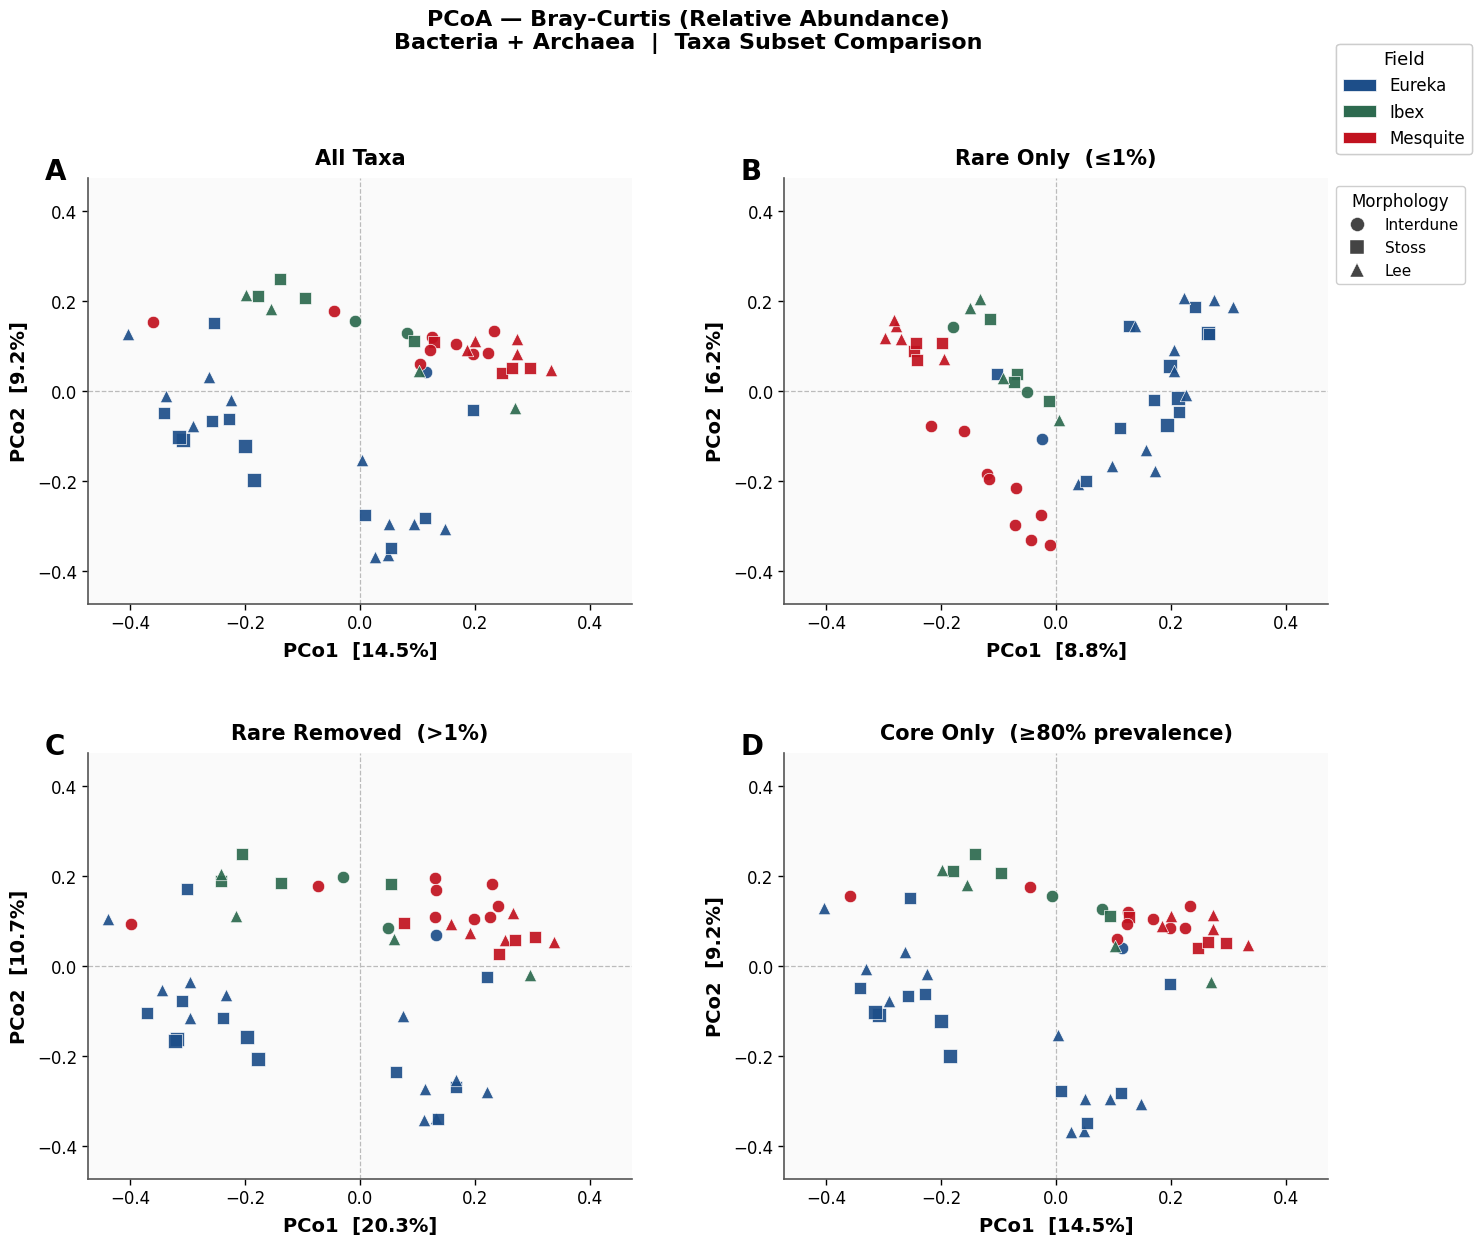

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp

np.random.seed(42)

# ============================
# PATHS
# ============================
REL_PATH  = "/content/zotutab_decontam_RelAbund_Final.csv"
META_PATH = "/content/PERM_metadata.csv"

# ============================
# LOAD RELATIVE ABUNDANCE
# already standardised — no rename map needed
# ============================
raw = pd.read_csv(REL_PATH, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# LOAD METADATA
# ============================
meta = pd.read_csv(META_PATH).rename(
    columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]
all_samples      = eureka_samples + mesquite_samples + ibex_samples
shared           = all_samples

metadata = pd.DataFrame(
    {"Field": [get_field(s) for s in all_samples]},
    index=all_samples
)

shared_meta = meta.loc[meta.index.isin(all_samples)]
meta_aln    = shared_meta.reindex(all_samples)

cont_vars = ["GrainSize", "Moisture"]
for c in cont_vars:
    meta_aln[c] = pd.to_numeric(meta_aln[c], errors="coerce")
meta_aln[cont_vars] = meta_aln[cont_vars].fillna(
    meta_aln[cont_vars].median())
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

print(f"Eureka: {len(eureka_samples)}  "
      f"Mesquite: {len(mesquite_samples)}  "
      f"Ibex: {len(ibex_samples)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
relabund_t = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
relabund_t = relabund_t.reindex(all_samples)
relabund_t.index.name   = None
relabund_t.columns.name = None

print(f"Sample x ZOTU matrix: {relabund_t.shape}")

# ============================
# RARE / DOMINANT SPLIT
# individual sample max per ZOTU
# ============================
zotu_max       = relabund_t.max(axis=0)
rare_zotus     = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_col)["Phylum"].to_dict()
core_zotus  = [z for z in relabund_t.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# FOUR SUBSETS
# ============================
all_taxa     = relabund_t.copy()
rare_only    = relabund_t[rare_zotus].copy()
rare_removed = relabund_t[dominant_zotus].copy()
core_only    = relabund_t[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa:     {all_taxa.shape[1]}")
print(f"  Rare only:    {rare_only.shape[1]}")
print(f"  Rare removed: {rare_removed.shape[1]}")
print(f"  Core only:    {core_only.shape[1]}")
print(f"  Core phyla:   {len(core_phyla)}")

# ============================
# BRAY-CURTIS DISTANCE
# ============================
def bray_curtis_dm(df):
    arr = df.values.astype(float)
    bc  = squareform(pdist(arr, metric="braycurtis"))
    return np.nan_to_num(bc, nan=1.0)

print("\nComputing distance matrices...")
dist_all     = bray_curtis_dm(all_taxa)
dist_rare    = bray_curtis_dm(rare_only)
dist_no_rare = bray_curtis_dm(rare_removed)
dist_core    = bray_curtis_dm(core_only)

dm_all     = DistanceMatrix(dist_all,     ids=all_samples)
dm_rare    = DistanceMatrix(dist_rare,    ids=all_samples)
dm_no_rare = DistanceMatrix(dist_no_rare, ids=all_samples)
dm_core    = DistanceMatrix(dist_core,    ids=all_samples)
print("Done.")

# ============================
# VERIFIED R² FORMULA
# Anderson (2001)
# ============================
def manual_r2(d, groups):
    g  = np.array(groups)
    n  = len(g)
    ss_t = np.sum(d ** 2) / n
    ss_w = sum(
        np.sum(d[np.ix_(np.where(g == x)[0],
                         np.where(g == x)[0])] ** 2) /
        len(np.where(g == x)[0])
        for x in np.unique(g)
        if len(np.where(g == x)[0]) > 1
    )
    return (ss_t - ss_w) / ss_t if ss_t > 0 else np.nan

def sig_str(p):
    try:
        p = float(p)
        return "***" if p < 0.001 else "**" if p < 0.01 \
               else "*" if p < 0.05 else "ns"
    except:
        return ""

# # ============================
# # PERMANOVA + PERMDISP
# # ============================
cat_vars  = ["Field", "Morphology"]
cont_vars_perm = ["GrainSize", "Moisture"]
all_vars  = cat_vars + cont_vars_perm

SUBSETS = [
    ("All taxa",     dm_all,     dist_all),
    ("Rare only",    dm_rare,    dist_rare),
    ("Rare removed", dm_no_rare, dist_no_rare),
    ("Core only",    dm_core,    dist_core),
]

records = []
for subset_label, dm, dist_arr in SUBSETS:
    print(f"\nRunning PERMANOVA: {subset_label}...")
    for var in all_vars:
        grp   = meta_aln[var] if var in meta_aln.columns \
                else metadata["Field"]
        res_p = permanova(dm, grp, permutations=999)
        r2    = manual_r2(dist_arr, grp.values)
        p_val = float(res_p["p-value"])
        f_val = float(res_p["test statistic"])

        disp_p = np.nan
        if var in cat_vars:
            try:
                res_d  = permdisp(dm, grp, permutations=999)
                disp_p = float(res_d["p-value"])
            except:
                pass

        records.append({
            "Subset":     subset_label,
            "Variable":   var,
            "R2":         round(r2, 4),
            "F":          round(f_val, 3),
            "p":          round(p_val, 4),
            "Sig":        sig_str(p_val),
            "PERMDISP_p": round(disp_p, 4)
                         if not np.isnan(disp_p) else "N/A",
        })

results_df = pd.DataFrame(records)


print("\n" + "="*65)
print("PERMANOVA RESULTS")
print("="*65)
print(results_df.to_string(index=False))

# ============================
# HEATMAP
# ============================
SUBSET_ORDER = ["All taxa", "Rare only", "Rare removed", "Core only"]
VAR_ORDER    = ["Field", "Morphology", "GrainSize", "Moisture"]
VAR_LABELS   = ["Field", "Morphology", "Grain Size", "Moisture"]

r2_mat = np.zeros((4, 4))
p_mat  = np.ones((4, 4))

for si, subset in enumerate(SUBSET_ORDER):
    for vi, var in enumerate(VAR_ORDER):
        row = results_df[
            (results_df["Subset"]   == subset) &
            (results_df["Variable"] == var)
        ]
        if len(row):
            r2_mat[si, vi] = row["R2"].values[0]
            p_mat[si,  vi] = row["p"].values[0]

cmap = LinearSegmentedColormap.from_list(
    "r2map", ["#f7fbff","#c6dbef","#6baed6",
              "#2171b5","#08306b"])

fig_h, ax_h = plt.subplots(figsize=(10, 5))
fig_h.patch.set_facecolor("white")
fig_h.subplots_adjust(bottom=0.28, top=0.88,
                       left=0.18, right=0.88)

im = ax_h.imshow(r2_mat, cmap=cmap, aspect="auto",
                 vmin=0, vmax=max(0.22, r2_mat.max() + 0.02))

for si in range(4):
    for vi in range(4):
        r2 = r2_mat[si, vi]
        p  = p_mat[si,  vi]
        tc = "white" if r2 > 0.13 else "#1a1a2e"
        ax_h.text(vi, si - 0.12, f"{r2*100:.1f}%",
                  ha="center", va="center",
                  fontsize=10, fontweight="bold", color=tc)
        ax_h.text(vi, si + 0.22, sig_str(p),
                  ha="center", va="center",
                  fontsize=8, color=tc, alpha=0.85)

for x in np.arange(-0.5, 4, 1):
    ax_h.axvline(x, color="white", lw=2)
for y in np.arange(-0.5, 4, 1):
    ax_h.axhline(y, color="white", lw=2)

ax_h.set_xticks(range(4))
ax_h.set_xticklabels(VAR_LABELS, fontsize=11, rotation=30,
                     ha="right", rotation_mode="anchor")
ax_h.set_yticks(range(4))
ax_h.set_yticklabels(SUBSET_ORDER, fontsize=11,
                     fontweight="bold")
ax_h.tick_params(length=0)
for sp in ax_h.spines.values():
    sp.set_visible(False)

ax_h.set_title(
    "PERMANOVA — R² by Metadata Variable Across Taxa Subsets\n"
    "(Bray-Curtis on relative abundance)",
    fontsize=12, fontweight="bold", pad=12)

cb = fig_h.colorbar(im, ax=ax_h, shrink=0.85,
                     pad=0.015, aspect=18)
cb.set_label("R²", fontsize=11, labelpad=8,
             rotation=0, ha="left")
cb.ax.tick_params(labelsize=9)
cb.outline.set_visible(False)

fig_h.text(0.18, 0.05,
           "*** p<0.001    ** p<0.01    * p<0.05"
           "    ns = not significant",
           fontsize=9, color="#444444",
           transform=fig_h.transFigure)

plt.show()

# ============================
# PCoA FIGURE
# ============================
def pcoa(dist_arr):
    D2         = dist_arr ** 2
    row_mean   = D2.mean(axis=1, keepdims=True)
    col_mean   = D2.mean(axis=0, keepdims=True)
    grand_mean = D2.mean()
    B          = -0.5 * (D2 - row_mean - col_mean + grand_mean)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos     = eigvals > 0
    coords  = eigvecs[:, pos] * np.sqrt(eigvals[pos])
    var_exp = eigvals[pos] / eigvals[pos].sum() * 100
    return coords, var_exp

coords_all,     var_all     = pcoa(dist_all)
coords_rare,    var_rare    = pcoa(dist_rare)
coords_no_rare, var_no_rare = pcoa(dist_no_rare)
coords_core,    var_core    = pcoa(dist_core)

# ============================
# MORPH STYLE
# compound types map to base position symbol
# ============================
FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

MORPH_STYLE = {
    "Interdune":        ("o",  80),   # circle
    "Stoss":            ("s",  75),   # square
    "Lee":              ("^",  80),   # triangle
    "Stoss, Depth":     ("s",  75),   # stoss
    "Stoss , Depth":    ("s",  75),   # stoss
    "Interdune, Depth": ("o",  75),   # interdune
    "Stoss, Star":      ("s", 110),   # stoss
    "Stoss , Star":     ("s", 110),   # stoss
    "Lee, Star":        ("^",  80),   # lee
    "Stoss, Crest":     ("s",  75),   # stoss
}

fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

fig_p, axes = plt.subplots(
    2, 2, figsize=(16, 13),
    gridspec_kw={"hspace": 0.35, "wspace": 0.28})
fig_p.patch.set_facecolor("white")

panel_data = [
    (axes[0,0], coords_all,     var_all,
     "All Taxa",                     "A"),
    (axes[0,1], coords_rare,    var_rare,
     "Rare Only  (≤1%)",             "B"),
    (axes[1,0], coords_no_rare, var_no_rare,
     "Rare Removed  (>1%)",          "C"),
    (axes[1,1], coords_core,    var_core,
     "Core Only  (≥80% prevalence)", "D"),
]

# shared axis limits
all_x = np.concatenate([coords_all[:,0],    coords_rare[:,0],
                         coords_no_rare[:,0], coords_core[:,0]])
all_y = np.concatenate([coords_all[:,1],    coords_rare[:,1],
                         coords_no_rare[:,1], coords_core[:,1]])
pad  = 0.08
half = max(abs(all_x).max(), abs(all_y).max()) * (1 + pad)

for ax, coords, var_exp, title, lbl in panel_data:
    n_plot = min(len(shared), coords.shape[0])
    for i in range(n_plot):
        fc     = FIELD_COLORS.get(fields[i], "gray")
        mk, sz = MORPH_STYLE.get(morphs[i], ("o", 80))
        ax.scatter(coords[i,0], coords[i,1],
                   color=fc, marker=mk, s=sz,
                   edgecolors="white", linewidths=0.5,
                   alpha=0.92, zorder=3)

    ax.axhline(0, color="#bbbbbb", lw=0.9, ls="--", zorder=1)
    ax.axvline(0, color="#bbbbbb", lw=0.9, ls="--", zorder=1)
    ax.set_xlabel(f"PCo1  [{var_exp[0]:.1f}%]",
                  fontsize=14, fontweight="bold", labelpad=6)
    ax.set_ylabel(f"PCo2  [{var_exp[1]:.1f}%]",
                  fontsize=14, fontweight="bold", labelpad=6)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.text(-0.08, 1.05, lbl, transform=ax.transAxes,
            fontsize=20, fontweight="bold", va="top")
    ax.tick_params(labelsize=12, length=4, width=1.0)
    ax.set_facecolor("#fafafa")
    ax.set_xlim(-half, half)
    ax.set_ylim(-half, half)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["bottom", "left"]:
        ax.spines[sp].set_color("#555555")
        ax.spines[sp].set_linewidth(1.2)

# ============================
# LEGENDS
# morphology: 3 symbols only
# ============================
field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 10),
    ("Stoss",     "s", 10),
    ("Lee",       "^", 10),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#444444",
               markeredgecolor="white",
               markeredgewidth=0.3,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

leg1 = fig_p.legend(
    handles=field_handles, title="Field",
    loc="upper left", bbox_to_anchor=(.9, 0.99),
    frameon=True, framealpha=0.95, edgecolor="#cccccc",
    fontsize=12, title_fontsize=13)
leg2 = fig_p.legend(
    handles=morph_handles, title="Morphology",
    loc="upper left", bbox_to_anchor=(.9, 0.88),
    frameon=True, framealpha=0.95, edgecolor="#cccccc",
    fontsize=11, title_fontsize=12)
fig_p.add_artist(leg1)

fig_p.suptitle(
    "PCoA — Bray-Curtis (Relative Abundance)\n"
    "Bacteria + Archaea  |  Taxa Subset Comparison",
    fontsize=16, fontweight="bold", y=1.01)

plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

sample_cols = [s for s in df.columns[1:-7] if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

# ============================
# COMPLETE PHYLUM RENAME MAP
# ============================
rename_map = {
    'actinobacteria':        'actinomycetota',
    'firmicutes':            'bacillota',
    'bacteroidetes':         'bacteroidota',
    'chloroflexi':           'chloroflexota',
    'cyanobacteria':         'cyanobacteriota',
    'proteobacteria':        'pseudomonadota',
    'pseudomonadot':         'pseudomonadota',
    'planctomycetes':        'planctomycetota',
    'gemmatimonadetes':      'gemmatimonadota',
    'verrucomicrobia':       'verrucomicrobiota',
    'acidobacteria':         'acidobacteriota',
    'nitrospirae':           'nitrospirota',
    'chlamydiae':            'chlamydiota',
    'elusimicrobia':         'elusimicrobiota',
    'spirochaetes':          'spirochaetota',
    'tenericutes':           'mycoplasmatota',
    'fusobacteria':          'fusobacteriota',
    'thermodesulfobacteria': 'thermodesulfobacteriota',
    'deinococcus-thermus':   'deinococcota',
    'armatimonadetes':       'armatimonadota',
    'thermotogae':           'thermotogota',
}

eukaryote_phyla = [
    'chlorophyta', 'discosea', 'eukaryota', 'tubulinea',
    'phaeophyceae', 'streptophyta', 'bacillariophyta', 'chordata',
    'ciliophora', 'oomycota', 'basidiomycota', 'eustigmatophyceae',
    'ascomycota', 'choanoflagellatea',
]

# ============================
# STANDARDISE AND FILTER
# ============================
df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip().replace(rename_map)

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    ~df["Phylum"].isin(eukaryote_phyla) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna() &
    ~df["Phylum"].str.startswith("unclassified", na=True)
].copy()

print(f"Total prokaryotic ZOTUs: {len(micro)}")
print(f"Unique phyla before grouping: {micro['Phylum'].nunique()}")

# ============================
# CHECK FOR DUPLICATE / STALE PHYLUM NAMES
# ============================
all_phyla = sorted(micro['Phylum'].unique())
print(f"\nAll {len(all_phyla)} unique phyla after renaming:")
for p in all_phyla:
    print(f"  {p}")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]

print(f"\nEureka:   {len(eureka_samples)} samples")
print(f"Mesquite: {len(mesquite_samples)} samples")
print(f"Ibex:     {len(ibex_samples)} samples")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()
print(f"\nTotal phyla after aggregation: {len(phylum_grouped)}")

# ============================
# FIELD MEANS AND PREVALENCE
# ============================
def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

e_prev = get_prev(phylum_grouped, eureka_samples)
m_prev = get_prev(phylum_grouped, mesquite_samples)
i_prev = get_prev(phylum_grouped, ibex_samples)

eureka_mean   = phylum_grouped[eureka_samples].mean(axis=1)
mesquite_mean = phylum_grouped[mesquite_samples].mean(axis=1)
ibex_mean     = phylum_grouped[ibex_samples].mean(axis=1)
max_field_mean = pd.concat(
    [eureka_mean, mesquite_mean, ibex_mean], axis=1).max(axis=1)

# ============================
# CLASSIFY EACH PHYLUM
# ============================
# strict core = ≥80% prevalence in ALL THREE fields
core_all  = (e_prev >= 0.80) & (m_prev >= 0.80) & (i_prev >= 0.80)

# partial core = ≥80% in at least one but not all three fields
core_e    = e_prev >= 0.80
core_m    = m_prev >= 0.80
core_i    = i_prev >= 0.80
partial   = (core_e | core_m | core_i) & ~core_all

# dominant = >1% mean in at least one field
dominant  = max_field_mean >= 1.0

# ============================
# BUILD SUMMARY TABLE
# ============================
summary = pd.DataFrame({
    "Eureka_prev":    e_prev.round(3),
    "Mesquite_prev":  m_prev.round(3),
    "Ibex_prev":      i_prev.round(3),
    "Eureka_mean":    eureka_mean.round(4),
    "Mesquite_mean":  mesquite_mean.round(4),
    "Ibex_mean":      ibex_mean.round(4),
    "Max_field_mean": max_field_mean.round(4),
    "Core_all":       core_all,
    "Partial_core":   partial,
    "Dominant":       dominant,
}).sort_values("Max_field_mean", ascending=False)

# ============================
# OVERLAP COUNTS
# ============================
n_total         = len(summary)
n_core_all      = core_all.sum()
n_core_dom      = (core_all & dominant).sum()
n_core_rare     = (core_all & ~dominant).sum()
n_partial       = partial.sum()
n_non_core      = (~core_all & ~partial).sum()
n_non_core_dom  = (~core_all & ~partial & dominant).sum()
n_non_core_rare = (~core_all & ~partial & ~dominant).sum()

print("\n" + "="*60)
print("PHYLUM CLASSIFICATION SUMMARY")
print("="*60)
print(f"Total prokaryotic phyla:              {n_total}")
print(f"  Core (≥80% all 3 fields):          {n_core_all}")
print(f"    Core + dominant (>1% mean):       {n_core_dom}")
print(f"    Core + rare (≤1% mean):           {n_core_rare}")
print(f"  Partial core (≥80% in 1-2 fields): {n_partial}")
print(f"  Non-core (<80% in all fields):      {n_non_core}")
print(f"    Non-core + dominant:              {n_non_core_dom}")
print(f"    Non-core + rare:                  {n_non_core_rare}")
print(f"\nCheck: {n_core_all} + {n_partial} + {n_non_core} = "
      f"{n_core_all + n_partial + n_non_core} (should = {n_total})")

# ============================
# PRINT EACH CATEGORY
# ============================
print("\n" + "="*60)
print("CORE + DOMINANT (≥80% all fields AND >1% mean)")
print("="*60)
for p in summary[core_all & dominant].index:
    print(f"  {p:<40} "
          f"E:{eureka_mean[p]:.2f}%  "
          f"M:{mesquite_mean[p]:.2f}%  "
          f"I:{ibex_mean[p]:.2f}%")

print("\n" + "="*60)
print("CORE + RARE (≥80% all fields BUT ≤1% mean)")
print("="*60)
for p in summary[core_all & ~dominant].index:
    print(f"  {p:<40} "
          f"E:{eureka_mean[p]:.4f}%  "
          f"M:{mesquite_mean[p]:.4f}%  "
          f"I:{ibex_mean[p]:.4f}%")

print("\n" + "="*60)
print("PARTIAL CORE (≥80% in 1 or 2 fields only)")
print("="*60)
for p in summary[partial].index:
    fields_core = []
    if core_e[p]: fields_core.append("Eureka")
    if core_m[p]: fields_core.append("Mesquite")
    if core_i[p]: fields_core.append("Ibex")
    print(f"  {p:<40} "
          f"core in: {', '.join(fields_core)}")
    print(f"  {'':40} "
          f"E prev:{e_prev[p]:.0%}  "
          f"M prev:{m_prev[p]:.0%}  "
          f"I prev:{i_prev[p]:.0%}")

print("\n" + "="*60)
print("NON-CORE (<80% prevalence in all fields)")
print("="*60)
for p in summary[~core_all & ~partial].index:
    dom_label = "dominant" if dominant[p] else "rare"
    print(f"  {p:<40} {dom_label:<10} "
          f"max mean: {max_field_mean[p]:.4f}%  "
          f"E prev:{e_prev[p]:.0%}  "
          f"M prev:{m_prev[p]:.0%}  "
          f"I prev:{i_prev[p]:.0%}")

# ============================
# SAVE SUMMARY CSV
# ============================
print("\nSaved: phylum_classification_final.csv")

Total prokaryotic ZOTUs: 5892
Unique phyla before grouping: 36

All 36 unique phyla after renaming:
  abditibacteriota
  acidobacteriota
  actinomycetota
  armatimonadota
  atribacterota
  bacillota
  bacteroidota
  balneolota
  bdellovibrionota
  campylobacterota
  candidatus melainabacteria
  candidatus saccharibacteria
  candidatus tectomicrobia
  chlamydiota
  chloroflexota
  cyanobacteriota
  deinococcota
  elusimicrobiota
  euryarchaeota
  fusobacteriota
  gemmatimonadota
  ignavibacteriota
  kiritimatiellota
  mycoplasmatota
  myxococcota
  nitrospirota
  planctomycetota
  pseudomonadota
  rhodothermota
  spirochaetota
  thaumarchaeota
  thermodesulfobacteriota
  thermomicrobiota
  thermotogota
  verrucomicrobiota
  vulcanimicrobiota

Eureka:   24 samples
Mesquite: 18 samples
Ibex:     10 samples

Total phyla after aggregation: 36

PHYLUM CLASSIFICATION SUMMARY
Total prokaryotic phyla:              36
  Core (≥80% all 3 fields):          20
    Core + dominant (>1% mean):       

/tmp/ipykernel_26613/2647007868.py:179: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for p in summary[core_all & dominant].index:
/tmp/ipykernel_26613/2647007868.py:188: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for p in summary[core_all & ~dominant].index:
/tmp/ipykernel_26613/2647007868.py:197: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for p in summary[partial].index:
/tmp/ipykernel_26613/2647007868.py:212: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for p in summary[~core_all & ~partial].index:


In [ ]:
#CORE,DOMINANT,Rare Along transect

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

In [ ]:
#CORE,DOMINANT,Rare Along transect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER PROKARYOTES
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# RARE / DOMINANT SPLIT
# rare = never exceeds 1% in any single sample
# ============================
zotu_max       = otu.max(axis=0)
rare_zotus     = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols
                    if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols
                    if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols
                    if get_field(s) == "Ibex"]

phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_col)["Phylum"].to_dict()
core_zotus  = [z for z in otu.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# BUILD FOUR SUBSETS
# ============================
otu_all      = otu.copy()
otu_rare     = otu[rare_zotus].copy()
otu_dominant = otu[dominant_zotus].copy()
otu_core     = otu[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa:     {otu_all.shape[1]} ZOTUs")
print(f"  Rare only:    {otu_rare.shape[1]} ZOTUs")
print(f"  Dominant:     {otu_dominant.shape[1]} ZOTUs")
print(f"  Core only:    {otu_core.shape[1]} ZOTUs "
      f"({len(core_phyla)} phyla)")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

subsets = [
    ("All Taxa",     otu_all),
    ("Rare Only",    otu_rare),
    ("Dominant",     otu_dominant),
    ("Core Only",    otu_core),
]

# ============================
# MANTEL TEST FUNCTION
# ============================
def run_mantel(field, sample_list, otu_subset,
               coord_map, n_perm=999):

    samps = [s for s in sample_list
             if s in otu_subset.index and s in coord_map]
    n     = len(samps)

    if n < 4:
        return None

    # geographic distance matrix
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis
    sub    = otu_subset.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # mantel test
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)

    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "p": p, "sig": sig,
        "samps": samps, "n": n,
        "x_geo": x_geo, "y_bc": y_bc,
    }

# ============================
# RUN ALL COMBINATIONS
# ============================
print("\n" + "="*60)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print("="*60)

all_results = {}
for subset_name, otu_sub in subsets:
    print(f"\n--- {subset_name} ---")
    all_results[subset_name] = {}
    for field, slist in transects.items():
        res = run_mantel(field, slist, otu_sub,
                         coord_map, n_perm=999)
        all_results[subset_name][field] = res
        if res:
            print(f"  {field:<15} "
                  f"r={res['r']:.3f}  "
                  f"p={res['p']:.4f}  "
                  f"{res['sig']}")
        else:
            print(f"  {field:<15} insufficient samples")

# ============================
# FIGURE
# 4 rows (subsets) x 3 cols (fields)
# ============================
subset_names = [s for s, _ in subsets]
field_names  = list(transects.keys())

fig, axes = plt.subplots(
    4, 3, figsize=(20, 24),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.patch.set_facecolor("white")

panel_labels = "ABCDEFGHIJKL"
panel_idx    = 0

# compute shared y limits per row
y_lims = {}
for subset_name in subset_names:
    all_y = []
    for field in field_names:
        res = all_results[subset_name].get(field)
        if res:
            all_y.extend(res["y_bc"].tolist())
    if all_y:
        y_lims[subset_name] = (
            min(all_y) * 0.97,
            max(all_y) * 1.03
        )
    else:
        y_lims[subset_name] = (0, 1)

for ri, subset_name in enumerate(subset_names):
    for fi, field in enumerate(field_names):
        ax    = axes[ri, fi]
        color = field_colors[field]
        res   = all_results[subset_name].get(field)

        # panel label
        ax.text(-0.08, 1.05, panel_labels[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        if res is None:
            ax.set_title(f"{field}\n(no data)",
                         fontsize=11, color=color)
            ax.set_visible(True)
            panel_idx += 1
            continue

        x = res["x_geo"]
        y = res["y_bc"]

        # scatter coloured by distance
        ax.scatter(x, y, c=x, cmap="plasma",
                   alpha=0.6, s=25, linewidths=0,
                   vmin=x.min(), vmax=x.max(),
                   zorder=3)

        # regression line + stats
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        r2   = r_val ** 2
        x_ln = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.85)

        ax.text(0.97, 0.05,
                f"Mantel r = {res['r']:.3f}\n"
                f"p = {res['p']:.4f} {res['sig']}\n"
                f"R² = {r2:.3f}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=9, style="italic",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="#cccccc",
                          alpha=0.9))

        # titles — only top row gets field name
        if ri == 0:
            ax.set_title(
                f"{field}\n(n={res['n']} samples)",
                fontsize=12, fontweight="bold",
                color=color)
        else:
            ax.set_title(
                f"{field}",
                fontsize=11, fontweight="bold",
                color=color)

        ax.set_xlabel("Pairwise Geographic Distance (m)",
                      fontsize=10, fontweight="bold")
        ax.set_ylabel("Bray-Curtis Dissimilarity",
                      fontsize=10, fontweight="bold")
        ax.set_ylim(y_lims[subset_name])
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

        panel_idx += 1

# ============================
# ROW LABELS — subset names
# ============================
row_y_positions = [0.87, 0.65, 0.43, 0.21]
for label, ypos in zip(subset_names, row_y_positions):
    fig.text(0.01, ypos, label,
             fontsize=13, fontweight="bold",
             va="center", rotation=90,
             color="#333333")

fig.suptitle(
    "Pairwise Bray-Curtis Dissimilarity vs Geographic Distance\n"
    "by Taxa Subset  |  Mantel test, Spearman, 999 permutations",
    fontsize=15, fontweight="bold", y=1.01)


plt.show()
